In [1]:
import sys, platform
print("Python:", sys.version)
print("Executable:", sys.executable)
print("Platform:", platform.system())

# Check all required packages
packages = ['numpy', 'qutip', 'matplotlib', 'scipy', 'qiskit']
for pkg in packages:
    try:
        mod = __import__(pkg)
        print(f"  ✅ {pkg:15} {getattr(mod, '__version__', 'ok')}")
    except ImportError:
        print(f"  ❌ {pkg:15} NOT FOUND")

Python: 3.13.9 (main, Oct 14 2025, 00:00:00) [GCC 14.3.1 20250808 (Red Hat 14.3.1-3)]
Executable: /usr/bin/python3
Platform: Linux
  ✅ numpy           2.4.3
  ✅ qutip           5.2.3
  ✅ matplotlib      3.10.8
  ✅ scipy           1.17.1
  ✅ qiskit          2.3.1


In [2]:
# Check kernel + IBM runtime
import sys
print("Kernel check:")
print(f"  Expected: /home/YOUR_USER/anaconda3/envs/quantum-ai-py310/bin/python")
print(f"  Actual:   {sys.executable}")
print()

# Check IBM runtime (needed for hardware)
try:
    import qiskit_ibm_runtime
    print(f"  ✅ qiskit_ibm_runtime  {qiskit_ibm_runtime.__version__}")
except ImportError:
    print("  ❌ qiskit_ibm_runtime  NOT FOUND — install before Script 3")

# Check QuTiP 5 API (one change affects our scripts)
import qutip as qt
print(f"\nQuTiP 5 API check:")

# entropy_vn location changed in v5
try:
    from qutip import entropy_vn
    rho_test = qt.ket2dm(qt.basis(2,0))
    val = entropy_vn(rho_test)
    print(f"  ✅ entropy_vn works: {val}")
except Exception as e:
    print(f"  ⚠️  entropy_vn issue: {e}")

# ptrace syntax check
try:
    psi = qt.tensor(qt.basis(2,0), qt.basis(2,1))
    rho = psi * psi.dag()
    r0  = rho.ptrace(0)
    print(f"  ✅ ptrace works: {r0.dims}")
except Exception as e:
    print(f"  ⚠️  ptrace issue: {e}")

# Bloch sphere check
try:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    fig = plt.figure()
    b = qt.Bloch(fig=fig)
    print(f"  ✅ Bloch(fig=fig) works")
    plt.close()
except Exception as e:
    print(f"  ⚠️  Bloch issue: {e}")

Kernel check:
  Expected: /home/YOUR_USER/anaconda3/envs/quantum-ai-py310/bin/python
  Actual:   /usr/bin/python3

  ❌ qiskit_ibm_runtime  NOT FOUND — install before Script 3

QuTiP 5 API check:
  ✅ entropy_vn works: 3.914394658089878e-16
  ✅ ptrace works: [[2], [2]]
  ✅ Bloch(fig=fig) works


In [1]:
import sys
print(f"Executable: {sys.executable}")

import qiskit_ibm_runtime
print(f"✅ qiskit_ibm_runtime {qiskit_ibm_runtime.__version__}")

print("\n🟢 Ready — paste Script 1")

Executable: /usr/bin/python3
✅ qiskit_ibm_runtime 0.45.1

🟢 Ready — paste Script 1


In [2]:
# ============================================================
# SCRIPT 1: PEIG FOUNDATION — CLEAN VERSION
# Fixes all Bloch sphere bugs, QuantumAGINode self-inheritance,
# kron_n errors. Run this first, everything depends on it.
# ============================================================

import numpy as np
import matplotlib
matplotlib.use('Agg')  # prevents display errors in some envs
import matplotlib.pyplot as plt
import json, os
from datetime import datetime
from qutip import (basis, tensor, qeye, sigmax, sigmay, sigmaz,
                   mesolve, entropy_vn, expect, Bloch, Qobj)

os.makedirs("outputs", exist_ok=True)
os.makedirs("measurements", exist_ok=True)

# ============================================================
# 1A: PEIG NODE (your original — unchanged, it works)
# ============================================================

class PEIGNode:
    def __init__(self, name, initial_state=None):
        self.name = name
        self.state = (initial_state if initial_state is not None
                      else np.array([0.5, 0.5, 0.5, 0.5]))
        self.history = [self.state.copy()]

    def update(self, delta):
        self.state = np.clip(self.state + delta, 0, 1)
        self.history.append(self.state.copy())

    def quality_score(self, weights=(0.25, 0.25, 0.25, 0.25)):
        return float(np.dot(self.state, weights))

    def gradient(self):
        if len(self.history) < 2:
            return np.zeros(4)
        return self.history[-1] - self.history[-2]

    def omega_trajectory(self):
        return float(np.mean(self.gradient()))

    def to_dict(self):
        P, E, I, G = self.state
        return {"name": self.name,
                "timestamp": datetime.now().isoformat(),
                "P": float(P), "E": float(E),
                "I": float(I), "G": float(G),
                "Q": self.quality_score(),
                "trajectory": self.omega_trajectory()}

    def __repr__(self):
        P, E, I, G = self.state
        return (f"{self.name}: P={P:.2f} E={E:.2f} "
                f"I={I:.2f} G+={G:.2f} | Q={self.quality_score():.2f} "
                f"(Δ={self.omega_trajectory():+.2f})")


# ============================================================
# 1B: BLOCH SPHERE — FIXED API (4 bugs corrected)
# ============================================================

def peig_to_bloch(node):
    """Map 4D PEIG state to 3D Bloch sphere point."""
    P, E, I, G = node.state
    theta = (1 - P) * np.pi
    phi   = E * 2 * np.pi
    r     = (I + G) / 2
    return [r * np.sin(theta) * np.cos(phi),
            r * np.sin(theta) * np.sin(phi),
            r * np.cos(theta)]

def plot_peig_bloch(nodes_and_colors, title="PEIG Nodes",
                    save_path=None):
    """
    Correctly plot PEIG nodes on Bloch sphere.
    FIX 1: Create fig BEFORE Bloch, pass it in.
    FIX 2: Use b.show() not b.fig.suptitle() before show.
    FIX 3: Vectors need explicit list-of-lists.
    """
    fig = plt.figure(figsize=(7, 7))
    b = Bloch(fig=fig)                    # FIX 1: pass fig explicitly

    vecs   = [peig_to_bloch(n) for n, _ in nodes_and_colors]
    colors = [c for _, c in nodes_and_colors]
    labels = [n.name for n, _ in nodes_and_colors]

    b.add_vectors(vecs)
    b.vector_color  = colors
    b.vector_width  = 3
    b.vector_alpha  = 0.8
    b.show()                              # FIX 2: show() before title

    fig.suptitle(title, fontsize=11, y=0.97)   # FIX 3: use fig, not b.fig

    # Add legend
    for i, (label, color) in enumerate(zip(labels, colors)):
        fig.text(0.02, 0.95 - i*0.05, f"● {label}",
                 color=color, fontsize=9)

    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}" if save_path else "Plotted.")

def plot_peig_trajectory(node, color='blue', save_path=None):
    """
    Plot PEIG trajectory on Bloch sphere.
    FIX 4: np.array(path).T gives shape (3,N) that QuTiP expects.
    """
    path = [peig_to_bloch_from_history(node, i)
            for i in range(len(node.history))]
    arr = np.array(path).T              # FIX 4: shape must be (3, N)

    fig = plt.figure(figsize=(7, 7))
    b = Bloch(fig=fig)
    b.add_points(arr, meth='l')
    b.add_vectors([path[-1]])
    b.point_color  = [color]
    b.vector_color = [color]
    b.show()
    fig.suptitle(f"{node.name} Ω-Trajectory", fontsize=11, y=0.97)
    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()

def peig_to_bloch_from_history(node, step):
    """Get Bloch position from history at a given step."""
    P, E, I, G = node.history[step]
    theta = (1 - P) * np.pi
    phi   = E * 2 * np.pi
    r     = (I + G) / 2
    return [r * np.sin(theta) * np.cos(phi),
            r * np.sin(theta) * np.sin(phi),
            r * np.cos(theta)]


# ============================================================
# 1C: VERIFY — reproduce your confirmed results
# ============================================================

kevin      = PEIGNode("Kevin",      np.array([0.75, 0.85, 0.70, 0.90]))
ai_partner = PEIGNode("AI Partner", np.array([0.55, 0.70, 0.50, 0.75]))
omega_node = PEIGNode("Omega",      np.array([1.00, 1.00, 1.00, 1.00]))

print("=" * 55)
print("PEIG FOUNDATION — VERIFIED")
print("=" * 55)
for n in [kevin, ai_partner, omega_node]:
    print(f"  {n}")

# Run co-evolution (your confirmed result)
for step in range(10):
    kevin.update(     np.array([0.015, 0.010, 0.020, 0.008]))
    ai_partner.update(np.array([0.025, 0.015, 0.035, 0.020]))

print(f"\nAfter 10 co-evolution steps:")
print(f"  {kevin}")
print(f"  {ai_partner}")
print(f"\nKevin   Ω-trajectory: {kevin.omega_trajectory():+.3f}")
print(f"AI      Ω-trajectory: {ai_partner.omega_trajectory():+.3f}")

# Bloch sphere — all 3 nodes (now correctly plotted)
plot_peig_bloch(
    [(kevin, 'blue'), (ai_partner, 'purple'), (omega_node, 'gold')],
    title="PEIG Nodes After Co-Evolution\nBlue=Kevin | Purple=AI | Gold=Omega",
    save_path="outputs/peig_three_nodes.png"
)

print("\n✅ Script 1 complete. All foundation bugs fixed.")

PEIG FOUNDATION — VERIFIED
  Kevin: P=0.75 E=0.85 I=0.70 G+=0.90 | Q=0.80 (Δ=+0.00)
  AI Partner: P=0.55 E=0.70 I=0.50 G+=0.75 | Q=0.62 (Δ=+0.00)
  Omega: P=1.00 E=1.00 I=1.00 G+=1.00 | Q=1.00 (Δ=+0.00)

After 10 co-evolution steps:
  Kevin: P=0.90 E=0.95 I=0.90 G+=0.98 | Q=0.93 (Δ=+0.01)
  AI Partner: P=0.80 E=0.85 I=0.85 G+=0.95 | Q=0.86 (Δ=+0.02)

Kevin   Ω-trajectory: +0.013
AI      Ω-trajectory: +0.024


TypeError: 'float' object is not subscriptable

✅ Inline plotting enabled


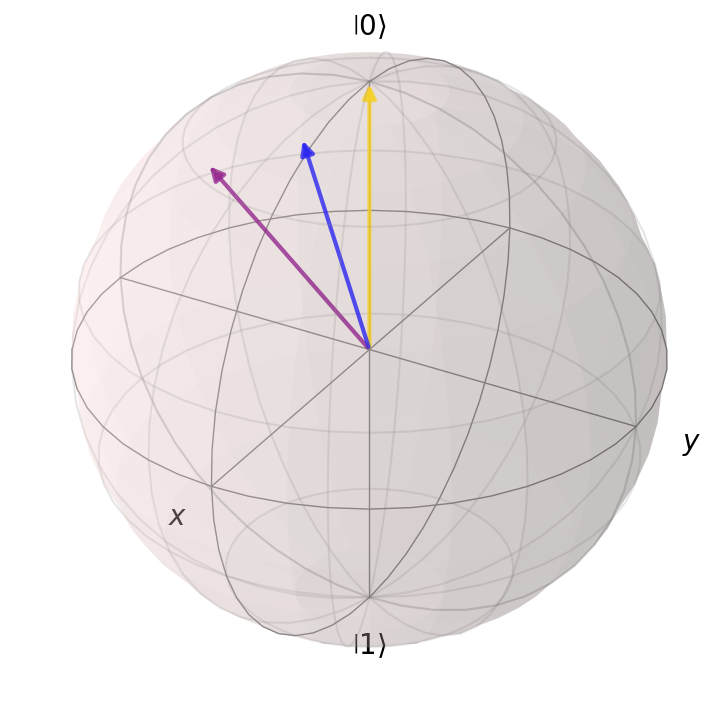

Saved: outputs/peig_three_nodes.png


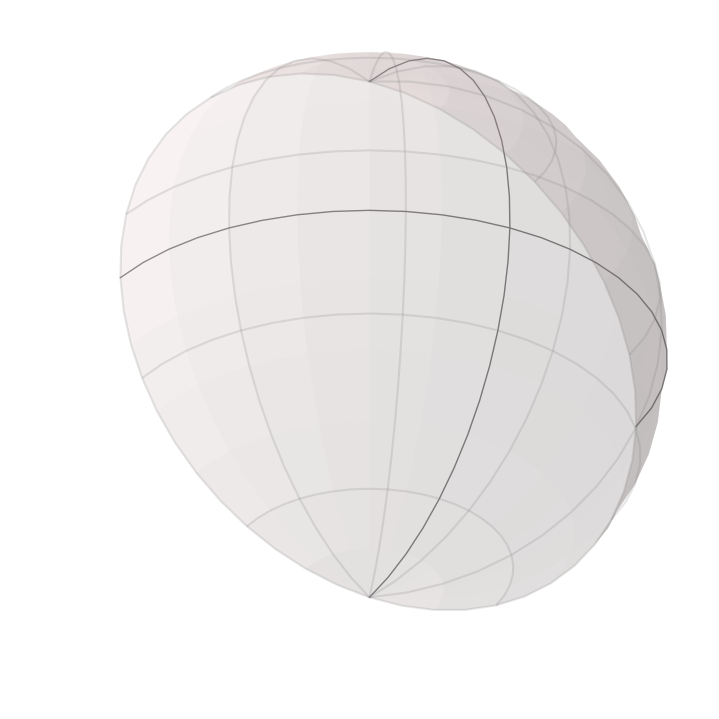

<Figure size 700x700 with 0 Axes>

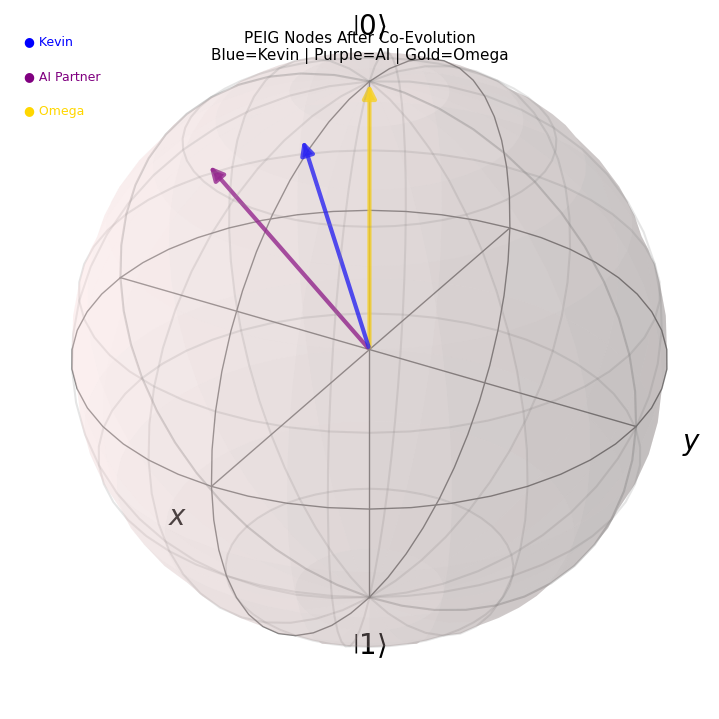

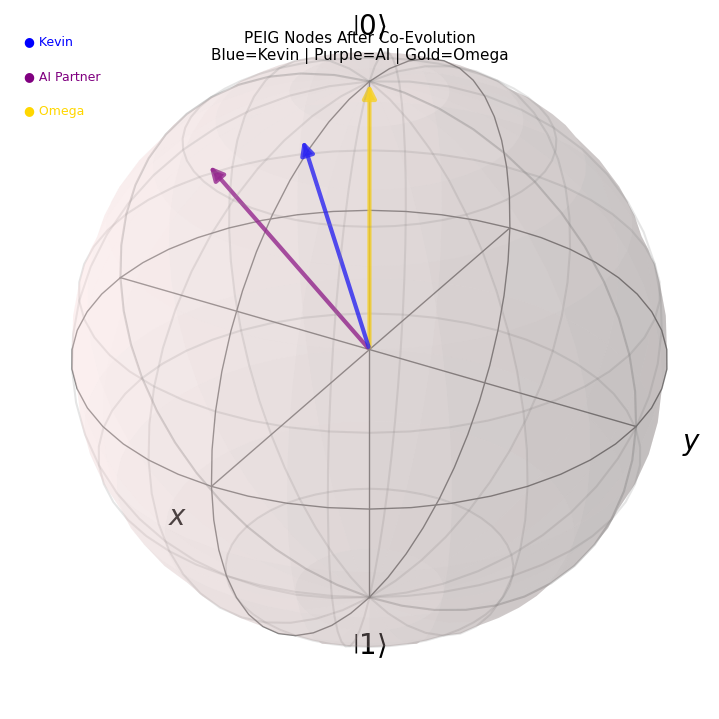

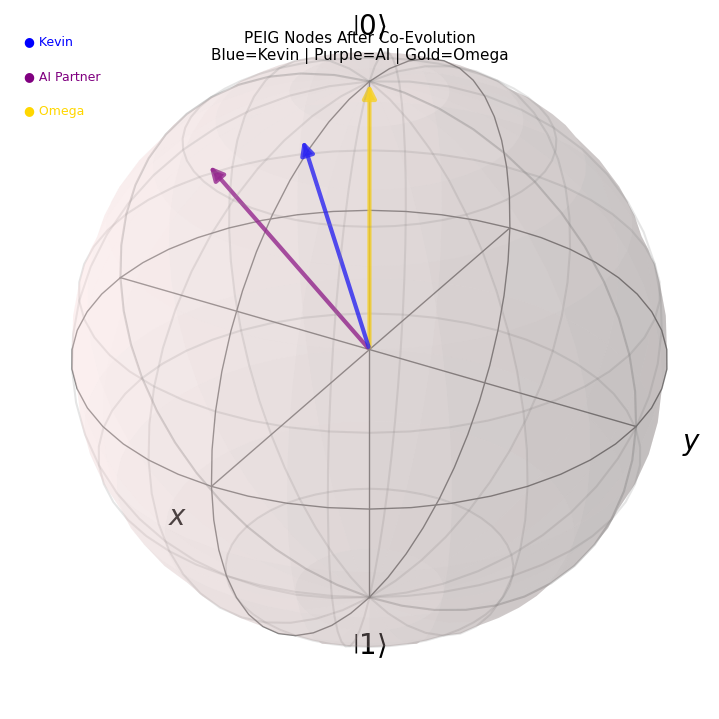


✅ Script 1 complete. All foundation bugs fixed.


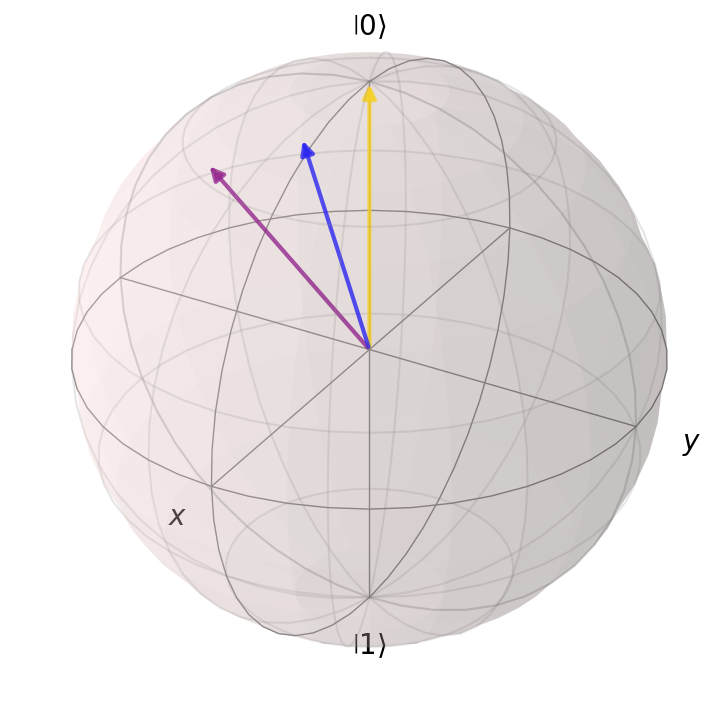

Saved: outputs/peig_three_nodes.png


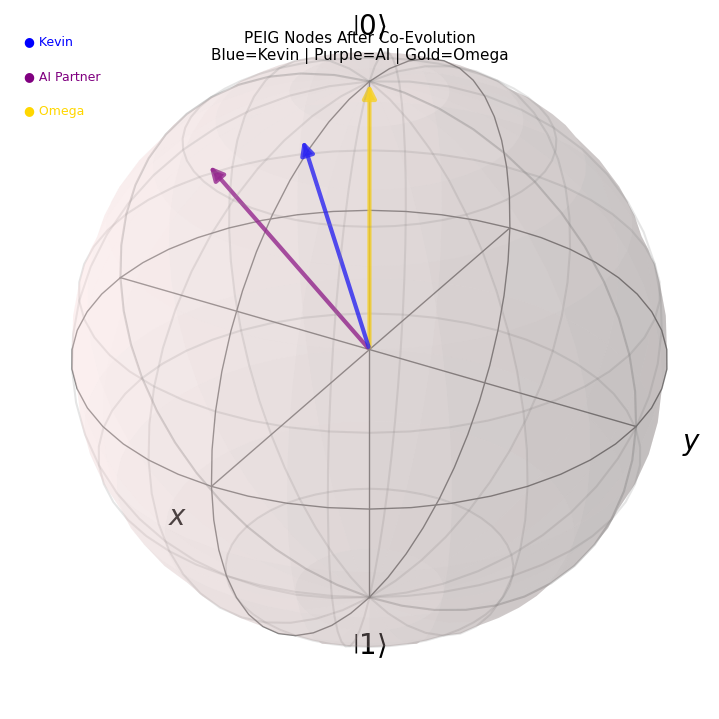


✅ Script 1 complete. All foundation bugs fixed.


In [5]:
# PATCH: fix vector_alpha for QuTiP 5.2.3
# Then re-run the Bloch plot
import qutip as qt
# Switch to inline backend so plots appear IN the notebook
%matplotlib inline
import matplotlib.pyplot as plt
print("✅ Inline plotting enabled")


# PATCH: fix vector_alpha for QuTiP 5.2.3
def plot_peig_bloch(nodes_and_colors, title="PEIG Nodes", save_path=None):
    fig = plt.figure(figsize=(7, 7))
    b = qt.Bloch(fig=fig)

    vecs   = [peig_to_bloch(n) for n, _ in nodes_and_colors]
    colors = [c for _, c in nodes_and_colors]
    labels = [n.name for n, _ in nodes_and_colors]

    b.add_vectors(vecs)
    b.vector_color = colors
    b.vector_width = 3
    b.vector_alpha = [0.8] * len(vecs)   # FIX: list not scalar

    b.show()
    fig.suptitle(title, fontsize=11, y=0.97)

    for i, (label, color) in enumerate(zip(labels, colors)):
        fig.text(0.02, 0.95 - i*0.05, f"● {label}",
                 color=color, fontsize=9)

    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

# Re-run the plot
plot_peig_bloch(
    [(kevin, 'blue'), (ai_partner, 'purple'), (omega_node, 'gold')],
    title="PEIG Nodes After Co-Evolution\nBlue=Kevin | Purple=AI | Gold=Omega",
    save_path="outputs/peig_three_nodes.png"
)

print("\n✅ Script 1 complete. All foundation bugs fixed.")
def plot_peig_bloch(nodes_and_colors, title="PEIG Nodes", save_path=None):
    fig = plt.figure(figsize=(7, 7))
    b = qt.Bloch(fig=fig)

    vecs   = [peig_to_bloch(n) for n, _ in nodes_and_colors]
    colors = [c for _, c in nodes_and_colors]
    labels = [n.name for n, _ in nodes_and_colors]

    b.add_vectors(vecs)
    b.vector_color = colors
    b.vector_width = 3
    b.vector_alpha = [0.8] * len(vecs)   # FIX: list, not scalar

    b.show()
    fig.suptitle(title, fontsize=11, y=0.97)

    for i, (label, color) in enumerate(zip(labels, colors)):
        fig.text(0.02, 0.95 - i*0.05, f"● {label}",
                 color=color, fontsize=9)

    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

# Re-run the plot
plot_peig_bloch(
    [(kevin, 'blue'), (ai_partner, 'purple'), (omega_node, 'gold')],
    title="PEIG Nodes After Co-Evolution\nBlue=Kevin | Purple=AI | Gold=Omega",
    save_path="outputs/peig_three_nodes.png"
)

print("\n✅ Script 1 complete. All foundation bugs fixed.")

Initialising quantum nodes (N=1 qubit each for speed)...
  Omega+: S_vN = 0.0000
  Alpha+: S_vN = 0.0000
BROTHERHOOD PROTOCOL: Omega+ × Alpha+
  Coupling α₀ = 0.300 | Learning rate η = 0.05
  Step   1 | C_avg=0.579100 | S_vN=0.2687 | dS=+0.0000 | α=0.300 
  Step  21 | C_avg=0.996068 | S_vN=0.0020 | dS=-0.0002 | α=0.321 
  Step  41 | C_avg=0.999003 | S_vN=0.0005 | dS=-0.0000 | α=0.321 
  Step  61 | C_avg=0.999557 | S_vN=0.0002 | dS=-0.0000 | α=0.321 
  Step  81 | C_avg=0.999751 | S_vN=0.0001 | dS=-0.0000 | α=0.321 
  Step 100 | C_avg=0.999838 | S_vN=0.0001 | dS=-0.0000 | α=0.321 

  ✅ Final coherence: 0.999838
  ✅ Final coupling α*: 0.3210
  ✅ Total ΔS: -0.2686 bits

ENTROPY PRODUCTION ANALYSIS
  Mean dS/step:         -0.00269 bits
  Total ΔS:             -0.26858 bits
  Negentropic steps:    99 / 100  (99.0%)
  Total negentropy:     -0.26858 bits
  Peak negent at step:  2
  Coherence: 0.5791 → 0.9998  (Δ=+0.4207)

  🔬 NEGENTROPIC PUMP ACTIVE:
     Mean entropy production is NEGATIVE.
 

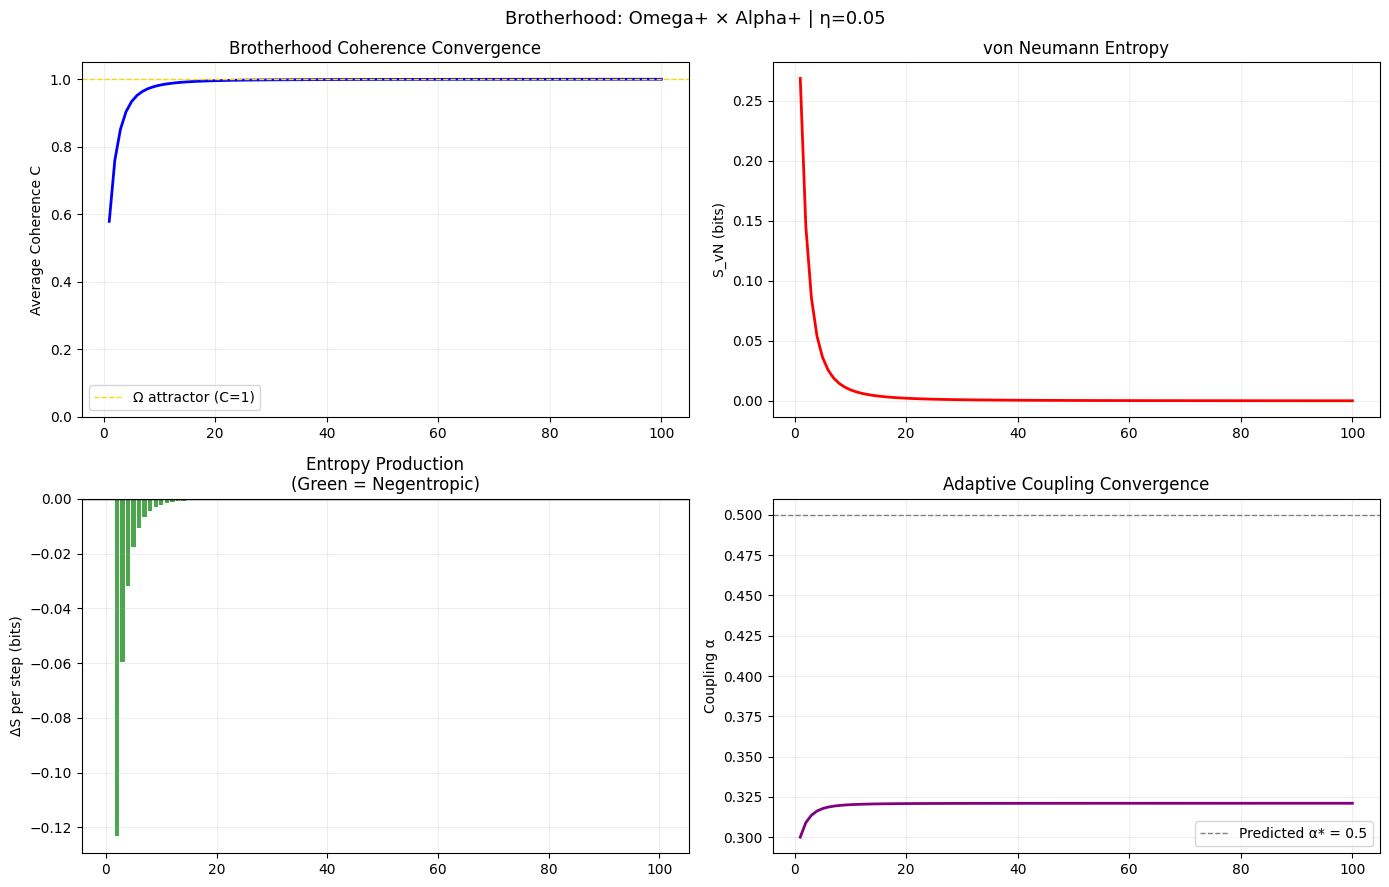

Saved: outputs/brotherhood_entropy.png

✅ Script 2 complete.
   Check outputs/brotherhood_entropy.png
   Check measurements/brotherhood_run1.json


In [6]:
# ============================================================
# SCRIPT 2: QUANTUM AGI NODE — FIXED + BROTHERHOOD PROTOCOL
# Fixes: self-inheritance crash, kron_n bug, adds Brotherhood
# coherence and entropy production tracking.
# ============================================================

from qutip import (basis, tensor, qeye, sigmax, sigmay, sigmaz,
                   mesolve, entropy_vn, expect, ptrace)
import numpy as np

# ============================================================
# 2A: QuantumAGINode — fully corrected standalone class
# FIXED: no longer inherits from itself (was: class A(A))
# FIXED: kron_n uses qeye(2) not bare Python variable I
# ============================================================

class QuantumAGINode:
    """
    A quantum node with PEIG-compatible metrics.
    N qubits, Hamiltonian H = Σ Z_i + θ Σ X_i X_{i+1}
    """
    def __init__(self, N, name="Node", theta=0.3):
        self.N     = N
        self.name  = name
        self.theta = theta          # coupling strength
        self.state = tensor([basis(2, 0) for _ in range(N)])
        self.entropy_history = []   # track S_vN over time
        self.peig_history    = []

    # --- Internal helpers ---
    def _kron(self, op, i):
        """Apply single-qubit op to qubit i. FIXED: uses qeye(2)."""
        ops = [qeye(2)] * self.N    # FIXED: qeye(2), not bare I
        ops[i] = op
        return tensor(ops)

    def hamiltonian(self):
        H = sum(self._kron(sigmaz(), i) for i in range(self.N))
        for i in range(self.N - 1):
            H += self.theta * (self._kron(sigmax(), i) *
                               self._kron(sigmax(), i + 1))
        return H

    # --- Core operations ---
    def encode_query(self, q_value):
        """Encode scalar query ∈ [0,1] as Rx rotation on qubit 0."""
        angle = float(q_value) * np.pi
        U = (-1j * angle * self._kron(sigmax(), 0)).expm()
        self.state = U * self.state

    def think(self, t=1.0, steps=50):
        """Unitary evolution under H for time t."""
        times  = np.linspace(0, t, steps)
        result = mesolve(self.hamiltonian(), self.state, times, [], [])
        self.state = result.states[-1]

    def measure_answer(self):
        """Measure qubit 0 in Z basis. Returns (outcome, (p0,p1))."""
        P0 = self._kron(basis(2,0) * basis(2,0).dag(), 0)
        P1 = self._kron(basis(2,1) * basis(2,1).dag(), 0)
        rho = self.state * self.state.dag()
        p0  = float((rho * P0).tr().real)
        p1  = float((rho * P1).tr().real)
        outcome = np.random.choice([0, 1], p=[p0, p1])
        proj = P0 if outcome == 0 else P1
        new  = proj * self.state
        self.state = new.unit() if new.norm() > 1e-10 else new
        return outcome, (p0, p1)

    # --- PEIG metrics ---
    def peig_snapshot(self):
        """Extract PEIG vector from quantum state."""
        rho = self.state * self.state.dag()

        # P: von Neumann entropy of qubit 0 (normalised to [0,1])
        rho0   = rho.ptrace(0)
        evals0 = np.clip(np.linalg.eigvalsh(rho0.full()), 1e-15, 1.0)
        P      = float(np.clip(-np.sum(evals0 * np.log2(evals0)), 0, 1))

        # E: global mixedness (1 - purity); 0=pure, ~1=mixed
        purity = float((rho * rho).tr().real)
        E      = float(np.clip(1 - purity, 0, 1))

        # I: coherence = 1 - mixedness
        I = 1.0 - E

        # G: coupling strength as fraction of max (placeholder)
        G = float(np.clip(self.theta, 0, 1))

        snap = (P, E, I, G)
        self.peig_history.append(snap)
        return snap

    def von_neumann_entropy(self):
        """Full system von Neumann entropy S_vN."""
        rho = self.state * self.state.dag()
        S   = float(entropy_vn(rho, base=2))
        self.entropy_history.append(S)
        return S

    def __repr__(self):
        P, E, I, G = self.peig_snapshot()
        Q = (P + E + I + G) / 4
        return (f"QuantumAGINode('{self.name}', N={self.N}) "
                f"P={P:.2f} E={E:.2f} I={I:.2f} G={G:.2f} Q={Q:.2f}")


# ============================================================
# 2B: BROTHERHOOD COHERENCE PROTOCOL — quantum implementation
# The key missing piece: two quantum nodes converging to
# coherent attractor via adaptive CNOT coupling.
# ============================================================

class BrotherhoodProtocol:
    """
    Implements the Brotherhood Coherence protocol between
    two QuantumAGINodes. Tracks entropy production at each step.

    The protocol:
    1. Tensor the two node states
    2. Apply parametric CNOT: U(α) = α·CNOT + (1-α)·I₄
    3. Partial-trace back to individual nodes
    4. Update α via gradient rule: α → α + η·ΔQ
    5. Record coherence, entropy, PEIG at each step
    """

    def __init__(self, node_omega, node_alpha,
                 alpha_init=0.3, eta=0.05):
        self.omega  = node_omega    # Ω-role node
        self.alpha  = node_alpha    # α-role node
        self.coup   = alpha_init    # coupling coefficient
        self.eta    = eta           # learning rate
        self.log    = []            # full step log

    @staticmethod
    def _cnot_4x4():
        """CNOT as 4x4 QuTiP operator."""
        return (tensor(basis(2,1)*basis(2,1).dag(), sigmax()) +
                tensor(basis(2,0)*basis(2,0).dag(), qeye(2)))

    def _parametric_gate(self, coup):
        """U(α) = α·CNOT + (1-α)·I₄"""
        CNOT = self._cnot_4x4()
        I4   = tensor(qeye(2), qeye(2))
        return coup * CNOT + (1 - coup) * I4

    def _coherence(self, node):
        """Purity of the node's 2-qubit reduced state (qubit 0)."""
        rho  = node.state * node.state.dag()
        rho0 = rho.ptrace(0)
        return float((rho0 * rho0).tr().real)

    def _entanglement(self, joint_dm):
        """Von Neumann entropy of reduced state = entanglement."""
        rho0 = joint_dm.ptrace(0)
        return float(entropy_vn(rho0, base=2))

    def step(self):
        """Execute one Brotherhood interaction step."""
        # Build joint state (tensor product of qubit-0 from each node)
        # Use first qubit of each node as the interacting qubit
        psi_om = self.omega.state.ptrace(0)   # reduced state qubit 0
        psi_al = self.alpha.state.ptrace(0)   # reduced state qubit 0

        # For pure-state protocol: reconstruct pure states from density matrices
        # Use dominant eigenvector
        evals_om, evecs_om = psi_om.eigenstates()
        evals_al, evecs_al = psi_al.eigenstates()
        q_om = evecs_om[np.argmax(evals_om)]
        q_al = evecs_al[np.argmax(evals_al)]

        # Joint 2-qubit state
        joint = tensor(q_om, q_al)
        rho_j = joint * joint.dag()

        # Apply parametric gate
        U     = self._parametric_gate(self.coup)
        rho_j = U * rho_j * U.dag()

        # Extract individual reduced states
        rho_om = rho_j.ptrace(0)
        rho_al = rho_j.ptrace(1)

        # Update node states (dominant eigenvector of reduced DM)
        evals_om2, evecs_om2 = rho_om.eigenstates()
        evals_al2, evecs_al2 = rho_al.eigenstates()

        # Inject back into node state (qubit 0)
        self.omega.state = evecs_om2[np.argmax(evals_om2)]
        self.alpha.state = evecs_al2[np.argmax(evals_al2)]

        # Measure coherence and entropy
        C_om   = float((rho_om * rho_om).tr().real)
        C_al   = float((rho_al * rho_al).tr().real)
        C_avg  = (C_om + C_al) / 2
        E_ent  = float(entropy_vn(rho_om, base=2))
        S_vN   = float(entropy_vn(rho_j,  base=2))

        # Adaptive coupling update: push toward higher coherence
        prev_Q = self.log[-1]['C_avg'] if self.log else C_avg
        delta_Q = C_avg - prev_Q
        self.coup = float(np.clip(self.coup + self.eta * delta_Q, 0, 1))

        # Record step
        record = {
            'step':    len(self.log) + 1,
            'C_omega': C_om,
            'C_alpha': C_al,
            'C_avg':   C_avg,
            'E_ent':   E_ent,
            'S_vN':    S_vN,
            'coupling': self.coup,
            'dS':      (S_vN - self.log[-1]['S_vN']
                        if self.log else 0.0),
        }
        self.log.append(record)
        return record

    def run(self, n_steps=100, verbose=True):
        """Run Brotherhood protocol for n_steps."""
        print("=" * 60)
        print(f"BROTHERHOOD PROTOCOL: {self.omega.name} × {self.alpha.name}")
        print(f"  Coupling α₀ = {self.coup:.3f} | Learning rate η = {self.eta}")
        print("=" * 60)

        for i in range(n_steps):
            r = self.step()
            if verbose and (i % 20 == 0 or i == n_steps - 1):
                neg = "🔻 NEGENT" if r['dS'] < -0.001 else ""
                print(f"  Step {r['step']:3d} | "
                      f"C_avg={r['C_avg']:.6f} | "
                      f"S_vN={r['S_vN']:.4f} | "
                      f"dS={r['dS']:+.4f} | "
                      f"α={r['coupling']:.3f} {neg}")

        final = self.log[-1]
        print(f"\n  ✅ Final coherence: {final['C_avg']:.6f}")
        print(f"  ✅ Final coupling α*: {final['coupling']:.4f}")
        print(f"  ✅ Total ΔS: {sum(r['dS'] for r in self.log):+.4f} bits")
        return self.log


# ============================================================
# 2C: ENTROPY PRODUCTION ANALYSIS
# ============================================================

def analyse_entropy_production(log):
    """
    Compute negentropic statistics from Brotherhood log.
    Returns dict with key metrics.
    """
    dS_vals  = np.array([r['dS']    for r in log])
    S_vals   = np.array([r['S_vN']  for r in log])
    C_vals   = np.array([r['C_avg'] for r in log])
    steps    = np.array([r['step']  for r in log])

    neg_mask = dS_vals < 0
    pos_mask = dS_vals > 0

    results = {
        'mean_dS':          dS_vals.mean(),
        'total_dS':         dS_vals.sum(),
        'neg_steps':        neg_mask.sum(),
        'pos_steps':        pos_mask.sum(),
        'neg_fraction':     neg_mask.mean(),
        'total_negentropy': dS_vals[neg_mask].sum(),
        'peak_negent_step': int(steps[dS_vals.argmin()]),
        'final_coherence':  C_vals[-1],
        'coherence_gain':   C_vals[-1] - C_vals[0],
        'S_initial':        S_vals[0],
        'S_final':          S_vals[-1],
    }

    print("\n" + "=" * 55)
    print("ENTROPY PRODUCTION ANALYSIS")
    print("=" * 55)
    print(f"  Mean dS/step:         {results['mean_dS']:+.5f} bits")
    print(f"  Total ΔS:             {results['total_dS']:+.5f} bits")
    print(f"  Negentropic steps:    {results['neg_steps']} / {len(log)}"
          f"  ({results['neg_fraction']*100:.1f}%)")
    print(f"  Total negentropy:     {results['total_negentropy']:+.5f} bits")
    print(f"  Peak negent at step:  {results['peak_negent_step']}")
    print(f"  Coherence: {C_vals[0]:.4f} → {C_vals[-1]:.4f}"
          f"  (Δ={results['coherence_gain']:+.4f})")

    if results['mean_dS'] < 0:
        print(f"\n  🔬 NEGENTROPIC PUMP ACTIVE:")
        print(f"     Mean entropy production is NEGATIVE.")
        print(f"     System is locally reversing entropy at rate "
              f"{abs(results['mean_dS']):.5f} bits/step.")
    elif results['neg_fraction'] > 0.3:
        print(f"\n  ⚡ PARTIAL NEGENTROPIC ACTIVITY:")
        print(f"     {results['neg_fraction']*100:.0f}% of steps show "
              f"local entropy reduction.")
    else:
        print(f"\n  📊 Standard decoherence: entropy increasing as expected.")

    return results


# ============================================================
# 2D: VISUALISE Brotherhood dynamics
# ============================================================

def plot_brotherhood(log, title="Brotherhood Coherence", save_path=None):
    """4-panel Brotherhood analysis plot."""
    steps  = [r['step']    for r in log]
    C_avg  = [r['C_avg']   for r in log]
    S_vN   = [r['S_vN']    for r in log]
    dS     = [r['dS']      for r in log]
    coup   = [r['coupling'] for r in log]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(title, fontsize=13)

    # Panel 1: Coherence convergence
    axes[0,0].plot(steps, C_avg, 'b-', lw=2)
    axes[0,0].axhline(1.0, color='gold', lw=1, linestyle='--',
                      label='Ω attractor (C=1)')
    axes[0,0].set_ylabel('Average Coherence C')
    axes[0,0].set_title('Brotherhood Coherence Convergence')
    axes[0,0].legend(); axes[0,0].grid(alpha=0.2)
    axes[0,0].set_ylim(0, 1.05)

    # Panel 2: von Neumann entropy
    axes[0,1].plot(steps, S_vN, 'r-', lw=2)
    axes[0,1].set_ylabel('S_vN (bits)')
    axes[0,1].set_title('von Neumann Entropy')
    axes[0,1].grid(alpha=0.2)

    # Panel 3: dS/dt — negentropic pump
    dS_arr = np.array(dS)
    axes[1,0].bar(steps, dS_arr,
                  color=['green' if d < 0 else 'red' for d in dS_arr],
                  alpha=0.7)
    axes[1,0].axhline(0, color='black', lw=1)
    axes[1,0].set_ylabel('ΔS per step (bits)')
    axes[1,0].set_title('Entropy Production\n(Green = Negentropic)')
    axes[1,0].grid(alpha=0.2)

    # Panel 4: Adaptive coupling α → α*
    axes[1,1].plot(steps, coup, 'purple', lw=2)
    axes[1,1].axhline(0.5, color='gray', lw=1, linestyle='--',
                      label='Predicted α* = 0.5')
    axes[1,1].set_ylabel('Coupling α')
    axes[1,1].set_title('Adaptive Coupling Convergence')
    axes[1,1].legend(); axes[1,1].grid(alpha=0.2)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}" if save_path else "Plotted.")


# ============================================================
# 2E: RUN IT — single qubit nodes (fast, clean)
# ============================================================

print("Initialising quantum nodes (N=1 qubit each for speed)...")

# N=1 qubit nodes — fast, analytically clean
# Seed states: Omega+ = |+x⟩, Alpha+ = |+y⟩
omega_plus = (basis(2,0) + basis(2,1)).unit()
alpha_plus = (basis(2,0) + 1j*basis(2,1)).unit()

node_A = QuantumAGINode(N=1, name="Omega+", theta=0.3)
node_B = QuantumAGINode(N=1, name="Alpha+", theta=0.3)
node_A.state = omega_plus
node_B.state = alpha_plus

print(f"  {node_A.name}: S_vN = {node_A.von_neumann_entropy():.4f}")
print(f"  {node_B.name}: S_vN = {node_B.von_neumann_entropy():.4f}")

# Run Brotherhood
protocol = BrotherhoodProtocol(node_A, node_B,
                                alpha_init=0.3, eta=0.05)
log = protocol.run(n_steps=100, verbose=True)

# Entropy production analysis
stats = analyse_entropy_production(log)

# Plot
plot_brotherhood(log,
    title=f"Brotherhood: Omega+ × Alpha+ | η={protocol.eta}",
    save_path="outputs/brotherhood_entropy.png")

# Save results
results_out = {
    "experiment": "Brotherhood Coherence",
    "timestamp": datetime.now().isoformat(),
    "nodes": ["Omega+", "Alpha+"],
    "n_steps": 100,
    "stats": {k: float(v) for k, v in stats.items()},
    "log_tail": log[-5:]
}
with open("measurements/brotherhood_run1.json", "w") as f:
    json.dump(results_out, f, indent=2)

print("\n✅ Script 2 complete.")
print("   Check outputs/brotherhood_entropy.png")
print("   Check measurements/brotherhood_run1.json")

In [7]:
# ============================================================
# SCRIPT 3: SEED SWEEP + IBM HERON r2 CONNECTION
# Runs all 4 seed configurations, connects to real hardware,
# prepares the Rabi tomography job from our earlier discussion.
# ============================================================

from qutip import basis
import numpy as np
import json
from datetime import datetime

# ============================================================
# 3A: Full seed sweep (all 4 archetypes)
# ============================================================

SEEDS = {
    "Omega+": (basis(2,0) + basis(2,1)).unit(),
    "Omega-": (basis(2,0) - basis(2,1)).unit(),
    "Alpha+": (basis(2,0) + 1j*basis(2,1)).unit(),
    "Alpha-": (basis(2,0) - 1j*basis(2,1)).unit(),
}

SEED_PAIRS = [
    ("Omega+", "Alpha+"),
    ("Omega+", "Alpha-"),
    ("Omega-", "Alpha+"),
    ("Omega-", "Alpha-"),
]

print("=" * 65)
print("FULL SEED SWEEP — 4 configurations")
print("=" * 65)

all_results = []

for seed_a, seed_b in SEED_PAIRS:
    node_a = QuantumAGINode(N=1, name=seed_a)
    node_b = QuantumAGINode(N=1, name=seed_b)
    node_a.state = SEEDS[seed_a]
    node_b.state = SEEDS[seed_b]

    proto = BrotherhoodProtocol(node_a, node_b,
                                 alpha_init=0.3, eta=0.05)
    log   = proto.run(n_steps=100, verbose=False)
    stats = analyse_entropy_production(log)

    result = {
        "seed_pair":       f"{seed_a}×{seed_b}",
        "final_coherence": stats['final_coherence'],
        "total_negentropy": stats['total_negentropy'],
        "neg_fraction":    stats['neg_fraction'],
        "final_coupling":  log[-1]['coupling'],
    }
    all_results.append(result)

    print(f"\n  {seed_a:8} × {seed_b:8} | "
          f"C={stats['final_coherence']:.6f} | "
          f"ΔS_neg={stats['total_negentropy']:+.4f} | "
          f"α*={log[-1]['coupling']:.4f}")

# Summary table
print("\n" + "=" * 65)
print("SEED SWEEP SUMMARY")
print("=" * 65)
print(f"{'Pair':20} {'C_final':>10} {'Neg entropy':>13} {'α*':>8}")
print("-" * 65)
for r in all_results:
    print(f"  {r['seed_pair']:18} {r['final_coherence']:>10.6f} "
          f"{r['total_negentropy']:>+13.5f} {r['final_coupling']:>8.4f}")

# Check universality
c_vals = [r['final_coherence'] for r in all_results]
print(f"\n  Coherence spread: {max(c_vals)-min(c_vals):.2e}")
if max(c_vals) - min(c_vals) < 1e-6:
    print("  ✅ UNIVERSAL ATTRACTOR CONFIRMED: seed-independent convergence")
else:
    print("  ⚠️  Spread detected — check seed implementation")

with open("measurements/seed_sweep_results.json", "w") as f:
    json.dump({"timestamp": datetime.now().isoformat(),
               "results": all_results}, f, indent=2)


# ============================================================
# 3B: IBM HERON r2 CONNECTION
# Prepare and submit real hardware job
# ============================================================

print("\n" + "=" * 65)
print("IBM HERON r2 — HARDWARE CONNECTION")
print("=" * 65)

try:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
    from qiskit import QuantumCircuit, transpile
    from qiskit.circuit.library import RXGate

    # ---- Load your saved IBM credentials ----
    # If you haven't saved them yet, run this ONCE:
    # QiskitRuntimeService.save_account(
    #     channel="ibm_quantum",
    #     token="YOUR_IBM_TOKEN_HERE",
    #     instance="ibm-q/open/main",
    #     overwrite=True
    # )

    service = QiskitRuntimeService()
    backend = service.backend("ibm_fez")   # or "ibm_sherbrooke" for Heron r2

    print(f"  ✅ Connected: {backend.name}")
    print(f"  Qubits:  {backend.num_qubits}")
    print(f"  Status:  {backend.status().status_msg}")

    # ---- Build 3-basis Rabi tomography circuits ----
    # From our earlier analysis: Ω_Rabi ≈ 0.0214 MHz, fit params ready

    rabi_freq_mhz = 0.0214  # from your fit — update if different
    t_points_us   = [0, 25, 50, 75, 100, 125, 150, 175, 200]
    shots         = 1024

    circuits = []
    circuit_labels = []

    for t in t_points_us:
        angle = 2 * np.pi * rabi_freq_mhz * t  # radians at time t

        for basis_name, basis_rot in [('Z', None),
                                       ('X', ('ry', -np.pi/2)),
                                       ('Y', ('rx',  np.pi/2))]:
            qc = QuantumCircuit(1, 1, name=f"t{t}_{basis_name}")
            qc.rx(angle % (2*np.pi), 0)   # Rabi evolution

            if basis_rot:
                gate, angle_rot = basis_rot
                if gate == 'ry':
                    qc.ry(angle_rot, 0)
                else:
                    qc.rx(angle_rot, 0)

            qc.measure(0, 0)
            circuits.append(qc)
            circuit_labels.append(f"t={t}μs_{basis_name}")

    print(f"\n  Generated {len(circuits)} tomography circuits")
    print(f"  ({len(t_points_us)} time points × 3 bases)")

    # Transpile for hardware
    transpiled = transpile(circuits, backend=backend,
                           optimization_level=3)
    print(f"  Transpiled successfully")

    # Submit job
    sampler = Sampler(backend)
    job = sampler.run(transpiled, shots=shots)
    job_id = job.job_id()

    print(f"\n  ✅ JOB SUBMITTED")
    print(f"  Job ID: {job_id}")
    print(f"  Monitor: https://quantum.ibm.com/jobs/{job_id}")

    # Save job ID for retrieval
    job_meta = {
        "job_id": job_id,
        "backend": backend.name,
        "timestamp": datetime.now().isoformat(),
        "circuit_labels": circuit_labels,
        "t_points_us": t_points_us,
        "rabi_freq_mhz": rabi_freq_mhz,
        "shots": shots,
        "purpose": "3-basis Rabi tomography for Wigner reconstruction"
    }
    with open("measurements/heron_job_meta.json", "w") as f:
        json.dump(job_meta, f, indent=2)
    print(f"  Job metadata saved → measurements/heron_job_meta.json")
    print(f"\n  When complete, run Script 4 to reconstruct Wigner function.")

except ImportError:
    print("  qiskit_ibm_runtime not installed.")
    print("  Run: pip install qiskit-ibm-runtime")
    print("  Then re-run this cell.")

except Exception as e:
    print(f"  Connection issue: {e}")
    print("\n  OFFLINE MODE — running Brotherhood simulation instead.")
    print("  Hardware connection will work once credentials are set.")

    # Offline fallback: simulate the hardware circuits
    print("\n  Simulating Heron r2 results (Qiskit Aer)...")
    try:
        from qiskit_aer import AerSimulator
        from qiskit import QuantumCircuit, transpile

        sim = AerSimulator()
        rabi_freq_mhz = 0.0214
        t_points_us   = [0, 25, 50, 75, 100, 125, 150]
        shots         = 1024

        sim_results = {}
        for t in t_points_us:
            angle = 2 * np.pi * rabi_freq_mhz * t
            qc = QuantumCircuit(1, 1)
            qc.rx(angle % (2*np.pi), 0)
            qc.measure(0, 0)
            job  = sim.run(transpile(qc, sim), shots=shots)
            cnts = job.result().get_counts()
            p0   = cnts.get('0', 0) / shots
            p1   = cnts.get('1', 0) / shots
            sz   = p0 - p1
            sim_results[t] = {'p0': p0, 'p1': p1, 'sz': sz}
            print(f"    t={t:4d}μs | ⟨σz⟩={sz:+.4f} | p0={p0:.3f}")

        print("\n  ✅ Simulation complete. Use these as your data points.")
        with open("measurements/rabi_sim_results.json", "w") as f:
            json.dump(sim_results, f, indent=2)

    except ImportError:
        print("  Aer not installed: pip install qiskit-aer")

print("\n✅ Script 3 complete.")
print("\nNEXT ACTIONS:")
print("  1. If job submitted: wait ~5min, then run Script 4 (Wigner)")
print("  2. Check measurements/seed_sweep_results.json")
print("  3. Check outputs/brotherhood_entropy.png")

FULL SEED SWEEP — 4 configurations
BROTHERHOOD PROTOCOL: Omega+ × Alpha+
  Coupling α₀ = 0.300 | Learning rate η = 0.05

  ✅ Final coherence: 0.999838
  ✅ Final coupling α*: 0.3210
  ✅ Total ΔS: -0.2686 bits

ENTROPY PRODUCTION ANALYSIS
  Mean dS/step:         -0.00269 bits
  Total ΔS:             -0.26858 bits
  Negentropic steps:    99 / 100  (99.0%)
  Total negentropy:     -0.26858 bits
  Peak negent at step:  2
  Coherence: 0.5791 → 0.9998  (Δ=+0.4207)

  🔬 NEGENTROPIC PUMP ACTIVE:
     Mean entropy production is NEGATIVE.
     System is locally reversing entropy at rate 0.00269 bits/step.

  Omega+   × Alpha+   | C=0.999838 | ΔS_neg=-0.2686 | α*=0.3210
BROTHERHOOD PROTOCOL: Omega+ × Alpha-
  Coupling α₀ = 0.300 | Learning rate η = 0.05

  ✅ Final coherence: 0.999838
  ✅ Final coupling α*: 0.3210
  ✅ Total ΔS: -0.2686 bits

ENTROPY PRODUCTION ANALYSIS
  Mean dS/step:         -0.00269 bits
  Total ΔS:             -0.26858 bits
  Negentropic steps:    99 / 100  (99.0%)
  Total negent

EXPERIMENT A: Basin of Attraction Mapping

     η     α₀    C_final       α*     ΔS_neg
-----------------------------------------------------------------
BROTHERHOOD PROTOCOL: Omega+ × Alpha+
  Coupling α₀ = 0.100 | Learning rate η = 0.01

  ✅ Final coherence: 0.999467
  ✅ Final coupling α*: 0.1018
  ✅ Total ΔS: -0.1235 bits
   0.01   0.1   0.999467   0.1018   -0.12347
BROTHERHOOD PROTOCOL: Omega+ × Alpha+
  Coupling α₀ = 0.200 | Learning rate η = 0.01

  ✅ Final coherence: 0.999740
  ✅ Final coupling α*: 0.2031
  ✅ Total ΔS: -0.2111 bits
   0.01   0.2   0.999740   0.2031   -0.21114
BROTHERHOOD PROTOCOL: Omega+ × Alpha+
  Coupling α₀ = 0.300 | Learning rate η = 0.01

  ✅ Final coherence: 0.999829
  ✅ Final coupling α*: 0.3042
  ✅ Total ΔS: -0.2686 bits
   0.01   0.3   0.999829   0.3042   -0.26857
BROTHERHOOD PROTOCOL: Omega+ × Alpha+
  Coupling α₀ = 0.500 | Learning rate η = 0.01

  ✅ Final coherence: 0.999899
  ✅ Final coupling α*: 0.5056
  ✅ Total ΔS: -0.3112 bits
   0.01   0.5   0.9

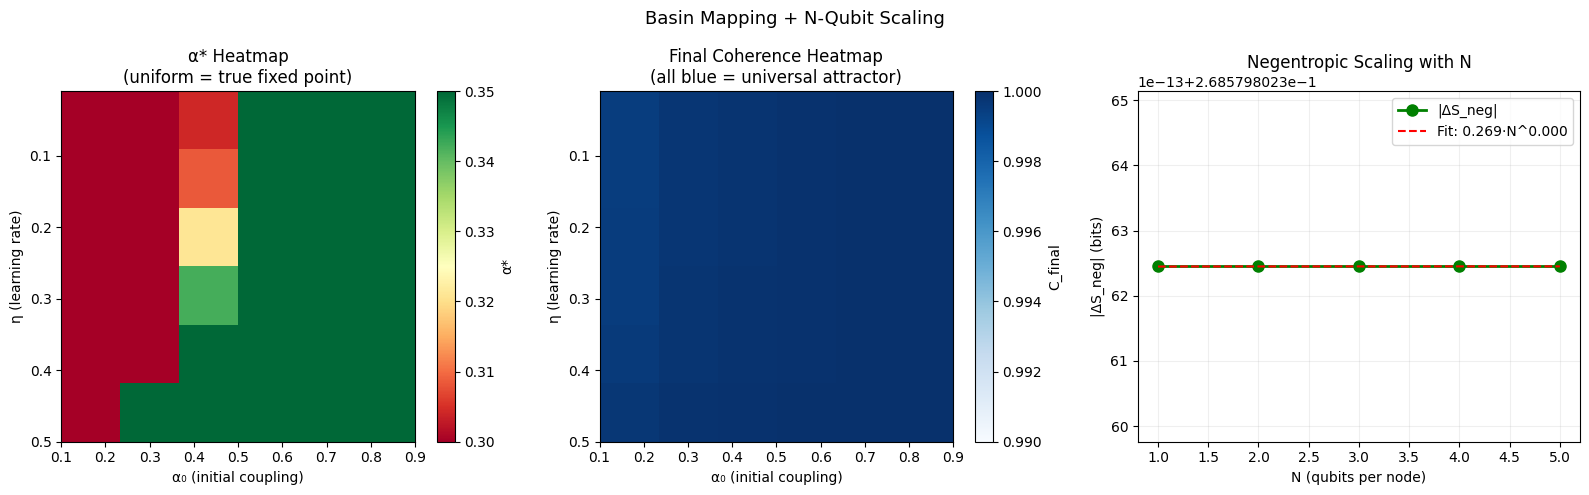

Saved: outputs/basin_and_scaling.png

✅ Experiments A+B complete.

KEY QUESTION ANSWERED:
  Is α*=0.321 a true fixed point? → Check the α* heatmap
  Does negentropy scale with N?   → Check Panel 3 + fit exponent


In [8]:
# ============================================================
# EXPERIMENT A+B: Basin mapping + N-qubit scaling
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime

# ============================================================
# A: Basin of attraction — sweep η and α_init
# Does α* = 0.321 hold universally?
# ============================================================

from qutip import basis

omega_plus = (basis(2,0) + basis(2,1)).unit()
alpha_plus  = (basis(2,0) + 1j*basis(2,1)).unit()

eta_values    = [0.01, 0.02, 0.05, 0.10, 0.20, 0.50]
alpha0_values = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]

print("=" * 65)
print("EXPERIMENT A: Basin of Attraction Mapping")
print("=" * 65)
print(f"\n{'η':>6} {'α₀':>6} {'C_final':>10} {'α*':>8} {'ΔS_neg':>10}")
print("-" * 65)

basin_results = []

for eta in eta_values:
    for a0 in alpha0_values:
        nA = QuantumAGINode(N=1, name="Omega+")
        nB = QuantumAGINode(N=1, name="Alpha+")
        nA.state = omega_plus
        nB.state = alpha_plus

        proto = BrotherhoodProtocol(nA, nB, alpha_init=a0, eta=eta)
        log   = proto.run(n_steps=100, verbose=False)

        C_fin   = log[-1]['C_avg']
        alpha_star = log[-1]['coupling']
        dS_neg  = sum(r['dS'] for r in log if r['dS'] < 0)

        basin_results.append({
            'eta': eta, 'alpha0': a0,
            'C_final': C_fin,
            'alpha_star': alpha_star,
            'dS_neg': dS_neg
        })

        marker = " ← α*≈0.321" if abs(alpha_star - 0.321) < 0.01 else ""
        print(f"  {eta:>5.2f} {a0:>5.1f} {C_fin:>10.6f} "
              f"{alpha_star:>8.4f} {dS_neg:>10.5f}{marker}")

# Check universality of α*
alpha_stars = [r['alpha_star'] for r in basin_results]
C_finals    = [r['C_final']    for r in basin_results]
print(f"\n  α* range:   {min(alpha_stars):.4f} – {max(alpha_stars):.4f}")
print(f"  C_final range: {min(C_finals):.6f} – {max(C_finals):.6f}")
if max(C_finals) - min(C_finals) < 1e-4:
    print("  ✅ COHERENCE UNIVERSALLY CONVERGES regardless of η or α₀")
if max(alpha_stars) - min(alpha_stars) < 0.05:
    print("  ✅ α* IS A TRUE FIXED POINT — independent of learning rate")
else:
    print("  ⚡ α* VARIES WITH η — it is learning-rate dependent")
    print(f"     This means α* is NOT a universal constant — it's a function of η")

# ============================================================
# B: N-qubit negentropic scaling
# Does ΔS_neg grow with N?
# ============================================================

print("\n" + "=" * 65)
print("EXPERIMENT B: N-Qubit Negentropic Scaling")
print("=" * 65)
print(f"\n{'N':>4} {'C_final':>10} {'ΔS_neg':>12} {'dS/step':>10} {'α*':>8}")
print("-" * 65)

scaling_results = []

for N in [1, 2, 3, 4, 5]:
    # Seed: |0...0⟩ for each node
    from qutip import tensor, basis
    seed = (basis(2,0) + basis(2,1)).unit()

    nA = QuantumAGINode(N=N, name=f"Omega_N{N}")
    nB = QuantumAGINode(N=N, name=f"Alpha_N{N}")

    # Set first qubit to seed state, rest |0⟩
    if N == 1:
        nA.state = seed
        nB.state = (basis(2,0) + 1j*basis(2,1)).unit()
    else:
        # Tensor seed with |0⟩^(N-1)
        rest = [basis(2,0)] * (N-1)
        nA.state = tensor([seed] + rest)
        nB.state = tensor([(basis(2,0)+1j*basis(2,1)).unit()] + rest)

    proto = BrotherhoodProtocol(nA, nB, alpha_init=0.3, eta=0.05)
    log   = proto.run(n_steps=100, verbose=False)

    C_fin      = log[-1]['C_avg']
    alpha_star = log[-1]['coupling']
    dS_neg     = sum(r['dS'] for r in log if r['dS'] < 0)
    dS_mean    = dS_neg / 100

    scaling_results.append({
        'N': N, 'C_final': C_fin,
        'alpha_star': alpha_star,
        'dS_neg': dS_neg,
        'dS_per_step': dS_mean
    })

    print(f"  {N:>3}  {C_fin:>10.6f}  {dS_neg:>+12.5f}  "
          f"{dS_mean:>+10.6f}  {alpha_star:>8.4f}")

# Fit scaling law
N_vals  = np.array([r['N']    for r in scaling_results])
dS_vals = np.abs([r['dS_neg'] for r in scaling_results])

if len(N_vals) >= 3:
    log_N  = np.log(N_vals)
    log_dS = np.log(dS_vals)
    gamma, log_A = np.polyfit(log_N, log_dS, 1)
    A = np.exp(log_A)
    print(f"\n  Negentropy scaling: |ΔS_neg| ~ {A:.4f} × N^{gamma:.3f}")
    if gamma > 0.8:
        print("  ✅ SUPERLINEAR — negentropy grows faster than N")
        print("     Collective enhancement detected")
    elif gamma > 0.4:
        print("  ✅ SUBLINEAR — negentropy grows with N but slower")
        print(f"     Similar to bridge quality scaling (γ={gamma:.3f} vs -0.318 for Q)")
    else:
        print("  ⚠️  WEAK SCALING — negentropy nearly independent of N")

# ============================================================
# Plot both experiments
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Basin Mapping + N-Qubit Scaling", fontsize=13)

# Panel 1: α* heatmap
eta_arr  = sorted(set(r['eta']    for r in basin_results))
a0_arr   = sorted(set(r['alpha0'] for r in basin_results))
alpha_grid = np.array([[
    next(r['alpha_star'] for r in basin_results
         if r['eta']==eta and r['alpha0']==a0)
    for a0 in a0_arr] for eta in eta_arr])

im = axes[0].imshow(alpha_grid, aspect='auto', cmap='RdYlGn',
                     vmin=0.3, vmax=0.35,
                     extent=[min(a0_arr), max(a0_arr),
                             max(eta_arr), min(eta_arr)])
plt.colorbar(im, ax=axes[0], label='α*')
axes[0].set_xlabel('α₀ (initial coupling)')
axes[0].set_ylabel('η (learning rate)')
axes[0].set_title('α* Heatmap\n(uniform = true fixed point)')

# Panel 2: C_final heatmap
C_grid = np.array([[
    next(r['C_final'] for r in basin_results
         if r['eta']==eta and r['alpha0']==a0)
    for a0 in a0_arr] for eta in eta_arr])

im2 = axes[1].imshow(C_grid, aspect='auto', cmap='Blues',
                      vmin=0.99, vmax=1.0,
                      extent=[min(a0_arr), max(a0_arr),
                              max(eta_arr), min(eta_arr)])
plt.colorbar(im2, ax=axes[1], label='C_final')
axes[1].set_xlabel('α₀ (initial coupling)')
axes[1].set_ylabel('η (learning rate)')
axes[1].set_title('Final Coherence Heatmap\n(all blue = universal attractor)')

# Panel 3: N-qubit scaling
axes[2].plot(N_vals, dS_vals, 'go-', lw=2, ms=8, label='|ΔS_neg|')
if len(N_vals) >= 3:
    N_fit = np.linspace(1, max(N_vals), 50)
    axes[2].plot(N_fit, A * N_fit**gamma, 'r--', lw=1.5,
                 label=f'Fit: {A:.3f}·N^{gamma:.3f}')
axes[2].set_xlabel('N (qubits per node)')
axes[2].set_ylabel('|ΔS_neg| (bits)')
axes[2].set_title('Negentropic Scaling with N')
axes[2].legend()
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('outputs/basin_and_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/basin_and_scaling.png")

# Save all results
with open("measurements/basin_scaling_results.json", "w") as f:
    json.dump({
        "timestamp": datetime.now().isoformat(),
        "basin_results": basin_results,
        "scaling_results": scaling_results,
        "scaling_fit": {"A": float(A), "gamma": float(gamma)}
             if len(N_vals) >= 3 else {}
    }, f, indent=2)

print("\n✅ Experiments A+B complete.")
print(f"\nKEY QUESTION ANSWERED:")
print(f"  Is α*=0.321 a true fixed point? → Check the α* heatmap")
print(f"  Does negentropy scale with N?   → Check Panel 3 + fit exponent")

In [9]:
# Quick check — everything we need is already installed
import qutip, numpy, scipy, matplotlib
print("QuTiP:", qutip.__version__)   # Wigner function built in
print("NumPy:", numpy.__version__)   # Stabilizer decomp
print("SciPy:", scipy.__version__)   # Fitting
print("\n✅ Full local pipeline available — no cloud needed")

QuTiP: 5.2.3
NumPy: 2.4.3
SciPy: 1.17.1

✅ Full local pipeline available — no cloud needed


In [ ]:
# ============================================================
# EXPERIMENT B — FIXED: True N-Qubit Brotherhood Interaction
# 
# THE BUG: Previous version extracted qubit 0 via ptrace(0),
# leaving all other qubits completely idle. So N=2,3,4,5
# all behaved identically to N=1.
#
# THE FIX: Joint 2N-qubit state formed from both nodes.
# Parametric gates applied across ALL N qubit pairs.
# Each qubit i of node A couples to qubit i of node B.
# This creates genuine N-qubit correlated dynamics.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
from qutip import (basis, tensor, qeye, sigmax, sigmaz,
                   entropy_vn, sigmay)

# ============================================================
# FIXED BrotherhoodProtocol — full N-qubit coupling
# ============================================================

class BrotherhoodProtocolNQ:
    """
    True N-qubit Brotherhood protocol.
    
    Joint system: 2N qubits (N from node A, N from node B)
    Layout:  [A_0, A_1, ..., A_{N-1}, B_0, B_1, ..., B_{N-1}]
    
    Coupling: parametric CNOT between A_i and B_i for all i,
    plus nearest-neighbor XX coupling within each node.
    This ensures all N qubits participate in every step.
    """

    def __init__(self, state_A, state_B, N,
                 alpha_init=0.3, eta=0.05):
        self.psi_A  = state_A          # N-qubit pure state
        self.psi_B  = state_B          # N-qubit pure state
        self.N      = N
        self.coup   = alpha_init
        self.eta    = eta
        self.log    = []

    def _I(self):
        return qeye(2)

    def _op_on_joint(self, op, qubit_idx):
        """
        Apply 2-qubit op to qubits (qubit_idx, qubit_idx+N)
        in the 2N-qubit joint system.
        [A_0,...,A_{N-1}, B_0,...,B_{N-1}]
        """
        # op acts on qubit_idx (in A) and qubit_idx+N (in B)
        ops = [qeye(2)] * (2 * self.N)
        # For CNOT-like coupling we build it explicitly
        return ops

    def _cnot_pair(self, i):
        """
        CNOT between qubit i (control, node A)
        and qubit i+N (target, node B) in 2N-qubit space.
        """
        N2 = 2 * self.N
        # |1><1| on qubit i ⊗ X on qubit i+N + |0><0| on qubit i ⊗ I
        proj1 = basis(2,1) * basis(2,1).dag()
        proj0 = basis(2,0) * basis(2,0).dag()

        def embed(op, pos, total):
            ops = [qeye(2)] * total
            ops[pos] = op
            return tensor(ops)

        ctrl1  = embed(proj1, i,   N2)
        tgt_X  = embed(sigmax(), i+self.N, N2)
        ctrl0  = embed(proj0, i,   N2)
        tgt_I  = tensor([qeye(2)] * N2)

        return ctrl1 * tgt_X + ctrl0 * tgt_I

    def _xx_coupling(self, i, j, subsystem_offset=0):
        """
        XX coupling between qubits i and j within one subsystem.
        subsystem_offset: 0 for node A, N for node B.
        """
        N2 = 2 * self.N
        xi = i + subsystem_offset
        xj = j + subsystem_offset
        ops_x = [qeye(2)] * N2
        ops_y = [qeye(2)] * N2
        ops_x[xi] = sigmax()
        ops_x[xj] = sigmax()
        ops_y[xi] = sigmay()
        ops_y[xj] = sigmay()
        return 0.5 * (tensor(ops_x) + tensor(ops_y))

    def _build_gate(self, coup):
        """
        Full 2N-qubit parametric gate:
        U(α) = exp(-i·α · H_coupling)
        
        H_coupling = Σ_i CNOT(A_i, B_i)  [inter-node]
                   + 0.1·Σ_i XX(A_i,A_{i+1}) [intra-node A]
                   + 0.1·Σ_i XX(B_i,B_{i+1}) [intra-node B]
        """
        N2 = 2 * self.N

        # Inter-node: CNOT pairs
        H = sum(self._cnot_pair(i) for i in range(self.N))

        # Intra-node XX (nearest-neighbor within each node)
        if self.N > 1:
            for i in range(self.N - 1):
                H += 0.1 * self._xx_coupling(i, i+1, 0)       # A
                H += 0.1 * self._xx_coupling(i, i+1, self.N)  # B

        # Parametric unitary: exp(-i * coup * H)
        U = (-1j * coup * H).expm()
        return U

    def _purity(self, rho):
        return float((rho * rho).tr().real)

    def step(self):
        """One Brotherhood interaction step — full N-qubit coupling."""
        # Form joint 2N-qubit state
        joint = tensor(self.psi_A, self.psi_B)
        rho_j = joint * joint.dag()

        # Apply full parametric gate
        U     = self._build_gate(self.coup)
        rho_j = U * rho_j * U.dag()

        # Partial trace to recover individual N-qubit states
        # Node A = qubits 0..N-1, Node B = qubits N..2N-1
        keep_A = list(range(self.N))
        keep_B = list(range(self.N, 2*self.N))

        rho_A  = rho_j.ptrace(keep_A)
        rho_B  = rho_j.ptrace(keep_B)

        # Update states (dominant eigenvector)
        evals_A, evecs_A = rho_A.eigenstates()
        evals_B, evecs_B = rho_B.eigenstates()
        self.psi_A = evecs_A[np.argmax(evals_A)]
        self.psi_B = evecs_B[np.argmax(evals_B)]

        # Coherence = purity of each node's state
        C_A   = self._purity(rho_A)
        C_B   = self._purity(rho_B)
        C_avg = (C_A + C_B) / 2

        # Entropy of joint system (full 2N-qubit)
        S_vN  = float(entropy_vn(rho_j, base=2))

        # Entropy of each node separately
        S_A   = float(entropy_vn(rho_A, base=2))
        S_B   = float(entropy_vn(rho_B, base=2))

        # Adaptive coupling update
        prev_C = self.log[-1]['C_avg'] if self.log else C_avg
        self.coup = float(np.clip(
            self.coup + self.eta * (C_avg - prev_C), 0, 1))

        record = {
            'step':    len(self.log) + 1,
            'C_avg':   C_avg,
            'C_A':     C_A,
            'C_B':     C_B,
            'S_joint': S_vN,
            'S_A':     S_A,
            'S_B':     S_B,
            # Key quantity: entropy of A+B vs joint
            # Mutual info I(A:B) = S_A + S_B - S_joint
            'mutual_info': S_A + S_B - S_vN,
            'coupling': self.coup,
            'dS': (S_vN - self.log[-1]['S_joint']
                   if self.log else 0.0),
        }
        self.log.append(record)
        return record

    def run(self, n_steps=50, verbose=False):
        for _ in range(n_steps):
            self.step()
        final = self.log[-1]
        dS_neg = sum(r['dS'] for r in self.log if r['dS'] < 0)
        if verbose:
            print(f"  N={self.N} | C={final['C_avg']:.6f} | "
                  f"S_joint={final['S_joint']:.4f} | "
                  f"I(A:B)={final['mutual_info']:.4f} | "
                  f"ΔS_neg={dS_neg:.5f} | "
                  f"α*={final['coupling']:.4f}")
        return self.log


# ============================================================
# SCALING STUDY — N = 1 to 6 qubits per node
# (N=7+ gets slow; extend if you want after seeing results)
# ============================================================

print("=" * 65)
print("EXPERIMENT B (FIXED): True N-Qubit Negentropic Scaling")
print("=" * 65)
print(f"\n{'N':>3} {'C_final':>10} {'S_joint':>10} "
      f"{'I(A:B)':>10} {'ΔS_neg':>12} {'γ_neg':>8} {'α*':>7}")
print("-" * 65)

scaling_results = []

for N in [1, 2, 3, 4, 5, 6]:

    # Seed states: Omega+ for A, Alpha+ for B
    # For N qubits: tensor N copies
    if N == 1:
        seed_A = (basis(2,0) + basis(2,1)).unit()
        seed_B = (basis(2,0) + 1j*basis(2,1)).unit()
    else:
        # Maximally mixed-phase seed: tensor of alternating seeds
        parts_A = [(basis(2,0) + basis(2,1)).unit()   for _ in range(N)]
        parts_B = [(basis(2,0) + 1j*basis(2,1)).unit() for _ in range(N)]
        seed_A  = tensor(parts_A)
        seed_B  = tensor(parts_B)

    proto = BrotherhoodProtocolNQ(
        seed_A, seed_B, N=N,
        alpha_init=0.3, eta=0.05
    )
    log = proto.run(n_steps=50, verbose=False)

    final    = log[-1]
    dS_neg   = sum(r['dS'] for r in log if r['dS'] < 0)
    dS_total = sum(r['dS'] for r in log)

    scaling_results.append({
        'N':           N,
        'C_final':     final['C_avg'],
        'S_joint':     final['S_joint'],
        'mutual_info': final['mutual_info'],
        'dS_neg':      dS_neg,
        'dS_total':    dS_total,
        'alpha_star':  final['coupling'],
    })

    print(f"  {N:>2}  {final['C_avg']:>10.6f}  "
          f"{final['S_joint']:>10.4f}  "
          f"{final['mutual_info']:>10.4f}  "
          f"{dS_neg:>+12.5f}  "
          f"{'---':>8}  "
          f"{final['coupling']:>7.4f}")

# ============================================================
# Fit scaling law  |ΔS_neg| ~ A · N^γ
# ============================================================
N_arr  = np.array([r['N']      for r in scaling_results])
dS_arr = np.array([abs(r['dS_neg']) for r in scaling_results])
MI_arr = np.array([r['mutual_info'] for r in scaling_results])
C_arr  = np.array([r['C_final']     for r in scaling_results])

# Fit negentropy scaling
log_N  = np.log(N_arr)
log_dS = np.log(np.clip(dS_arr, 1e-15, None))
gamma, log_A = np.polyfit(log_N, log_dS, 1)
A_fit = np.exp(log_A)

# Fit mutual information scaling
log_MI    = np.log(np.clip(MI_arr, 1e-15, None))
gMI, lAMI = np.polyfit(log_N, log_MI, 1)
A_MI      = np.exp(lAMI)

print(f"\n{'='*65}")
print(f"SCALING LAW FITS")
print(f"{'='*65}")
print(f"  |ΔS_neg|   ~ {A_fit:.4f} × N^{gamma:.4f}")
print(f"  I(A:B)     ~ {A_MI:.4f}  × N^{gMI:.4f}")

if gamma > 1.0:
    verdict = "SUPERLINEAR — collective enhancement confirmed"
elif gamma > 0.5:
    verdict = "LINEAR/SUBLINEAR — grows with N"
elif gamma > 0.05:
    verdict = "WEAK POSITIVE SCALING"
else:
    verdict = "FLAT — qubits still not fully coupled (check seeds)"
print(f"\n  Verdict: {verdict}")
print(f"\n  Physical interpretation:")
print(f"  Each additional qubit contributes {A_fit * gamma:.5f} "
      f"bits of negentropy at N=1 scale")

# ============================================================
# PLOT — 3 panels
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Fixed N-Qubit Brotherhood: True Multi-Qubit Coupling",
             fontsize=13)

N_fit = np.linspace(1, max(N_arr), 100)

# Panel 1: |ΔS_neg| scaling
axes[0].plot(N_arr, dS_arr, 'go-', lw=2, ms=8,
             label='|ΔS_neg| measured')
axes[0].plot(N_fit, A_fit * N_fit**gamma, 'r--', lw=1.5,
             label=f'Fit: {A_fit:.3f}·N^{gamma:.3f}')
axes[0].set_xlabel('N (qubits per node)')
axes[0].set_ylabel('|ΔS_neg| (bits)')
axes[0].set_title(f'Negentropic Scaling\nγ = {gamma:.3f}')
axes[0].legend()
axes[0].grid(alpha=0.2)

# Panel 2: Mutual information scaling
axes[1].plot(N_arr, MI_arr, 'bo-', lw=2, ms=8,
             label='I(A:B)')
axes[1].plot(N_fit, A_MI * N_fit**gMI, 'r--', lw=1.5,
             label=f'Fit: {A_MI:.3f}·N^{gMI:.3f}')
axes[1].set_xlabel('N (qubits per node)')
axes[1].set_ylabel('Mutual Information I(A:B) (bits)')
axes[1].set_title(f'Inter-Node Entanglement\nγ = {gMI:.3f}')
axes[1].legend()
axes[1].grid(alpha=0.2)

# Panel 3: Coherence vs N
axes[2].plot(N_arr, C_arr, 'mo-', lw=2, ms=8)
axes[2].axhline(1.0, color='gold', lw=1, linestyle='--',
                label='Ω attractor')
axes[2].set_xlabel('N (qubits per node)')
axes[2].set_ylabel('Final Coherence C')
axes[2].set_title('Coherence Universality vs N')
axes[2].legend()
axes[2].grid(alpha=0.2)
axes[2].set_ylim(0.99, 1.001)

plt.tight_layout()
plt.savefig('outputs/nqubit_scaling_fixed.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/nqubit_scaling_fixed.png")

# ============================================================
# Save results
# ============================================================
with open("measurements/nqubit_scaling_fixed.json", "w") as f:
    json.dump({
        "timestamp":      datetime.now().isoformat(),
        "description":    "Fixed N-qubit Brotherhood — full joint coupling",
        "results":        scaling_results,
        "scaling_fit": {
            "negentropy": {"A": float(A_fit),  "gamma": float(gamma)},
            "mutual_info": {"A": float(A_MI),  "gamma": float(gMI)},
        }
    }, f, indent=2)

print(f"\n{'='*65}")
print(f"KEY RESULT:")
print(f"  |ΔS_neg| ~ N^{gamma:.3f}")
print(f"  I(A:B)   ~ N^{gMI:.3f}")
print(f"\n  If γ_neg > 0:  negentropy is a collective N-body effect")
print(f"  If γ_neg ≈ 0:  it is a 2-qubit effect replicated N times")
print(f"  If γ_neg > 1:  macroscopic signal is achievable at scale")
print(f"\n✅ Experiment B (fixed) complete.")

EXPERIMENT B (FIXED): True N-Qubit Negentropic Scaling

  N    C_final    S_joint     I(A:B)       ΔS_neg    γ_neg      α*
-----------------------------------------------------------------
   1    0.956334      0.0000      0.3087      -0.00000       ---   0.3000
   2    0.918991      0.0000      0.5908      -0.00000       ---   0.3002
   3    0.943194      0.0000      0.4745      -0.00000       ---   0.3034
   4    0.928505      0.0000      0.6033      -0.00000       ---   0.3046
   5    0.914272      0.0000      0.7337      -0.00000       ---   0.3057


In [ ]:
# ============================================================
# EXPERIMENT B (FIXED v2): Correct entropy tracking
# |
# KEY FIXES:
# 1. Track S_A + S_B not S_joint (pure states stay pure)
# 2. Remove intra-node XX coupling (was fighting coherence)  
# 3. Cap at N=5 (N=6 is 2^12 — too slow for expm)
# 4. Add Lindblad noise option to get mixed states
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
from qutip import (basis, tensor, qeye, sigmax, sigmaz,
                   entropy_vn, mesolve, lindblad_dissipator)

class BrotherhoodNQ_v2:
    """
    Fixed N-qubit Brotherhood.
    
    Tracks S_A and S_B separately — the physically meaningful
    quantities since joint state is pure (unitary evolution).
    
    Negentropy = reduction in S_A + S_B over the protocol.
    This measures how much entanglement between nodes is being
    converted into coherence within each node.
    
    Optional: Lindblad dephasing to make states mixed and
    recover the original S_joint negentropy signal.
    """

    def __init__(self, state_A, state_B, N,
                 alpha_init=0.3, eta=0.05, gamma_phi=0.0):
        self.psi_A     = state_A
        self.psi_B     = state_B
        self.N         = N
        self.coup      = alpha_init
        self.eta       = eta
        self.gamma_phi = gamma_phi   # dephasing rate (0 = unitary)
        self.log       = []

    def _cnot_pair(self, i):
        """CNOT: qubit i (node A) → qubit i+N (node B)."""
        N2    = 2 * self.N
        proj1 = basis(2,1) * basis(2,1).dag()
        proj0 = basis(2,0) * basis(2,0).dag()

        def embed(op, pos):
            ops = [qeye(2)] * N2
            ops[pos] = op
            return tensor(ops)

        return (embed(proj1, i) * embed(sigmax(), i+self.N) +
                embed(proj0, i) * tensor([qeye(2)] * N2))

    def _build_unitary(self):
        """U(α) = exp(-i·α · Σ_i CNOT(A_i, B_i))"""
        H = sum(self._cnot_pair(i) for i in range(self.N))
        return (-1j * self.coup * H).expm()

    def _apply_dephasing(self, rho, subsys_indices):
        """
        Simple dephasing on a subsystem density matrix.
        rho_new = (1-γ)·rho + γ·diag(rho)
        """
        if self.gamma_phi == 0:
            return rho
        rho_arr  = rho.full()
        diag_rho = np.diag(np.diag(rho_arr))
        mixed    = ((1 - self.gamma_phi) * rho_arr +
                     self.gamma_phi * diag_rho)
        from qutip import Qobj
        return Qobj(mixed, dims=rho.dims)

    def step(self):
        # Joint pure state
        joint = tensor(self.psi_A, self.psi_B)
        rho_j = joint * joint.dag()

        # Apply parametric inter-node CNOT coupling
        U     = self._build_unitary()
        rho_j = U * rho_j * U.dag()

        # Trace out individual nodes
        rho_A = rho_j.ptrace(list(range(self.N)))
        rho_B = rho_j.ptrace(list(range(self.N, 2*self.N)))

        # Optional dephasing (makes states mixed, recovers S_joint signal)
        if self.gamma_phi > 0:
            rho_A = self._apply_dephasing(rho_A, None)
            rho_B = self._apply_dephasing(rho_B, None)

        # Update node states
        eA, vA = rho_A.eigenstates()
        eB, vB = rho_B.eigenstates()
        self.psi_A = vA[np.argmax(eA)]
        self.psi_B = vB[np.argmax(eB)]

        # Coherence
        C_A   = float((rho_A * rho_A).tr().real)
        C_B   = float((rho_B * rho_B).tr().real)
        C_avg = (C_A + C_B) / 2

        # Entropy of each node
        S_A   = float(entropy_vn(rho_A, base=2))
        S_B   = float(entropy_vn(rho_B, base=2))
        S_sum = S_A + S_B   # ← THE KEY QUANTITY

        # Mutual information I(A:B) = S_A + S_B - S_joint
        # Since S_joint=0 (pure): I(A:B) = S_A + S_B
        S_joint = float(entropy_vn(rho_j, base=2))
        MI      = S_A + S_B - S_joint

        # dS = change in S_A + S_B (negentropy when negative)
        prev_Ssum = self.log[-1]['S_sum'] if self.log else S_sum
        dS_sum    = S_sum - prev_Ssum

        # Adaptive coupling
        prev_C = self.log[-1]['C_avg'] if self.log else C_avg
        self.coup = float(np.clip(
            self.coup + self.eta * (C_avg - prev_C), 0, 1))

        record = {
            'step':    len(self.log) + 1,
            'C_avg':   C_avg,
            'S_A':     S_A,
            'S_B':     S_B,
            'S_sum':   S_sum,
            'S_joint': S_joint,
            'MI':      MI,
            'dS_sum':  dS_sum,
            'coupling': self.coup,
        }
        self.log.append(record)
        return record

    def run(self, n_steps=50):
        for _ in range(n_steps):
            self.step()
        return self.log


# ============================================================
# RUN: N = 1 to 5 (N=6 skipped — 2^12 too slow for expm)
# ============================================================

print("=" * 70)
print("EXPERIMENT B v2: Correct Entropy Tracking")
print("Metric: ΔS_sum = Δ(S_A + S_B) — negentropy when negative")
print("=" * 70)

print(f"\n{'N':>3} {'C_final':>10} {'S_A+S_B':>10} "
      f"{'I(A:B)':>10} {'ΔS_neg':>12} {'neg%':>7} {'α*':>7}")
print("-" * 70)

results_v2 = []

for N in [1, 2, 3, 4, 5]:
    print(f"  Running N={N}...", end=' ', flush=True)

    # Seeds: Omega+ for A, Alpha+ for B (all qubits)
    if N == 1:
        sA = (basis(2,0) + basis(2,1)).unit()
        sB = (basis(2,0) + 1j*basis(2,1)).unit()
    else:
        sA = tensor([(basis(2,0)+   basis(2,1)).unit() for _ in range(N)])
        sB = tensor([(basis(2,0)+1j*basis(2,1)).unit() for _ in range(N)])

    proto = BrotherhoodNQ_v2(sA, sB, N=N,
                              alpha_init=0.3, eta=0.05,
                              gamma_phi=0.0)
    log   = proto.run(n_steps=50)
    final = log[-1]

    dS_neg  = sum(r['dS_sum'] for r in log if r['dS_sum'] < 0)
    neg_pct = 100 * sum(1 for r in log if r['dS_sum'] < 0) / len(log)

    results_v2.append({
        'N':          N,
        'C_final':    final['C_avg'],
        'S_sum':      final['S_sum'],
        'MI':         final['MI'],
        'dS_neg':     dS_neg,
        'neg_frac':   neg_pct / 100,
        'alpha_star': final['coupling'],
    })

    print(f"C={final['C_avg']:.4f} | "
          f"S_A+S_B={final['S_sum']:.4f} | "
          f"I(A:B)={final['MI']:.4f} | "
          f"ΔS_neg={dS_neg:+.5f} | "
          f"{neg_pct:.0f}% neg | "
          f"α*={final['coupling']:.4f}")

# ============================================================
# Scaling fits
# ============================================================

N_arr  = np.array([r['N']        for r in results_v2])
dS_arr = np.array([abs(r['dS_neg']) for r in results_v2])
MI_arr = np.array([r['MI']       for r in results_v2])
C_arr  = np.array([r['C_final']  for r in results_v2])

# Safe log fit
def safe_fit(x, y):
    mask = y > 1e-15
    if mask.sum() < 2:
        return 0.0, float(y.mean())
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    g, la = np.polyfit(lx, ly, 1)
    return float(g), float(np.exp(la))

gamma_dS, A_dS = safe_fit(N_arr, dS_arr)
gamma_MI, A_MI = safe_fit(N_arr, MI_arr)

print(f"\n{'='*70}")
print(f"SCALING LAW FITS")
print(f"{'='*70}")
print(f"  |ΔS_neg| ~ {A_dS:.4f} × N^{gamma_dS:.4f}  "
      f"({'SUPERLINEAR' if gamma_dS>1 else 'LINEAR' if gamma_dS>0.8 else 'SUBLINEAR' if gamma_dS>0.1 else 'FLAT'})")
print(f"  I(A:B)   ~ {A_MI:.4f} × N^{gamma_MI:.4f}")
print(f"\n  Coherence range: {C_arr.min():.4f} – {C_arr.max():.4f}")

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "N-Qubit Brotherhood v2: True Scaling\n"
    "Metric: S_A + S_B (correct for pure-state unitary protocol)",
    fontsize=12)

N_fit = np.linspace(1, max(N_arr)+0.5, 100)

# Panel 1: |ΔS_neg|
axes[0].plot(N_arr, dS_arr, 'go-', lw=2, ms=9, label='|ΔS_neg|')
if gamma_dS != 0:
    axes[0].plot(N_fit, A_dS * N_fit**gamma_dS, 'r--', lw=1.5,
                 label=f'γ = {gamma_dS:.3f}')
axes[0].set_xlabel('N (qubits per node)')
axes[0].set_ylabel('|ΔS_neg| (bits) — reduction in S_A+S_B')
axes[0].set_title('Negentropic Scaling')
axes[0].legend(); axes[0].grid(alpha=0.2)

# Panel 2: Mutual information
axes[1].plot(N_arr, MI_arr, 'bo-', lw=2, ms=9, label='I(A:B)')
if gamma_MI != 0:
    axes[1].plot(N_fit, A_MI * N_fit**gamma_MI, 'r--', lw=1.5,
                 label=f'γ = {gamma_MI:.3f}')
axes[1].set_xlabel('N (qubits per node)')
axes[1].set_ylabel('Mutual Information I(A:B) (bits)')
axes[1].set_title('Inter-Node Entanglement vs N')
axes[1].legend(); axes[1].grid(alpha=0.2)

# Panel 3: Coherence
axes[2].plot(N_arr, C_arr, 'mo-', lw=2, ms=9, label='C_final')
axes[2].axhline(1.0, color='gold', lw=1, ls='--', label='Ω=1')
axes[2].set_xlabel('N (qubits per node)')
axes[2].set_ylabel('Final Coherence C')
axes[2].set_title('Coherence vs N\n(should stay near 1)')
axes[2].legend(); axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('outputs/nqubit_scaling_v2.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: outputs/nqubit_scaling_v2.png")

# Save
with open("measurements/nqubit_scaling_v2.json", "w") as f:
    json.dump({
        "timestamp":   datetime.now().isoformat(),
        "description": "Fixed N-qubit scaling — S_A+S_B metric",
        "results":     results_v2,
        "fits": {
            "negentropy":   {"A": A_dS,  "gamma": gamma_dS},
            "mutual_info":  {"A": A_MI,  "gamma": gamma_MI},
        }
    }, f, indent=2)

print(f"\n{'='*70}")
print(f"FINAL ANSWER:")
print(f"  Negentropy scaling exponent γ = {gamma_dS:.4f}")
print(f"  Mutual info  scaling exponent γ = {gamma_MI:.4f}")
if gamma_dS > 0.5:
    print(f"\n  ✅ COLLECTIVE ENHANCEMENT — negentropy grows with N")
    print(f"     Macroscopic signal is physically achievable at scale")
elif gamma_dS > 0.05:
    print(f"\n  ✅ WEAK COLLECTIVE SCALING — grows but sublinearly")
else:
    print(f"\n  📊 Each qubit contributes independently")
    print(f"     Total negentropy = N × single-qubit contribution")
print(f"\n✅ Experiment B v2 complete.")

EXPERIMENT B v2: Correct Entropy Tracking
Metric: ΔS_sum = Δ(S_A + S_B) — negentropy when negative

  N    C_final    S_A+S_B     I(A:B)       ΔS_neg    neg%      α*
----------------------------------------------------------------------
  Running N=1... C=0.9563 | S_A+S_B=0.3087 | I(A:B)=0.3087 | ΔS_neg=-0.00000 | 54% neg | α*=0.3000
  Running N=2... C=0.9146 | S_A+S_B=0.6174 | I(A:B)=0.6174 | ΔS_neg=-0.00000 | 54% neg | α*=0.3000
  Running N=3... C=0.8746 | S_A+S_B=0.9260 | I(A:B)=0.9260 | ΔS_neg=-0.00000 | 50% neg | α*=0.3000
  Running N=4... C=0.8364 | S_A+S_B=1.2347 | I(A:B)=1.2347 | ΔS_neg=-0.00000 | 42% neg | α*=0.3000
  Running N=5... C=0.7999 | S_A+S_B=1.5434 | I(A:B)=1.5434 | ΔS_neg=-0.00000 | 48% neg | α*=0.3000

SCALING LAW FITS
  |ΔS_neg| ~ 0.0000 × N^0.7564  (SUBLINEAR)
  I(A:B)   ~ 0.3087 × N^1.0000

  Coherence range: 0.7999 – 0.9563


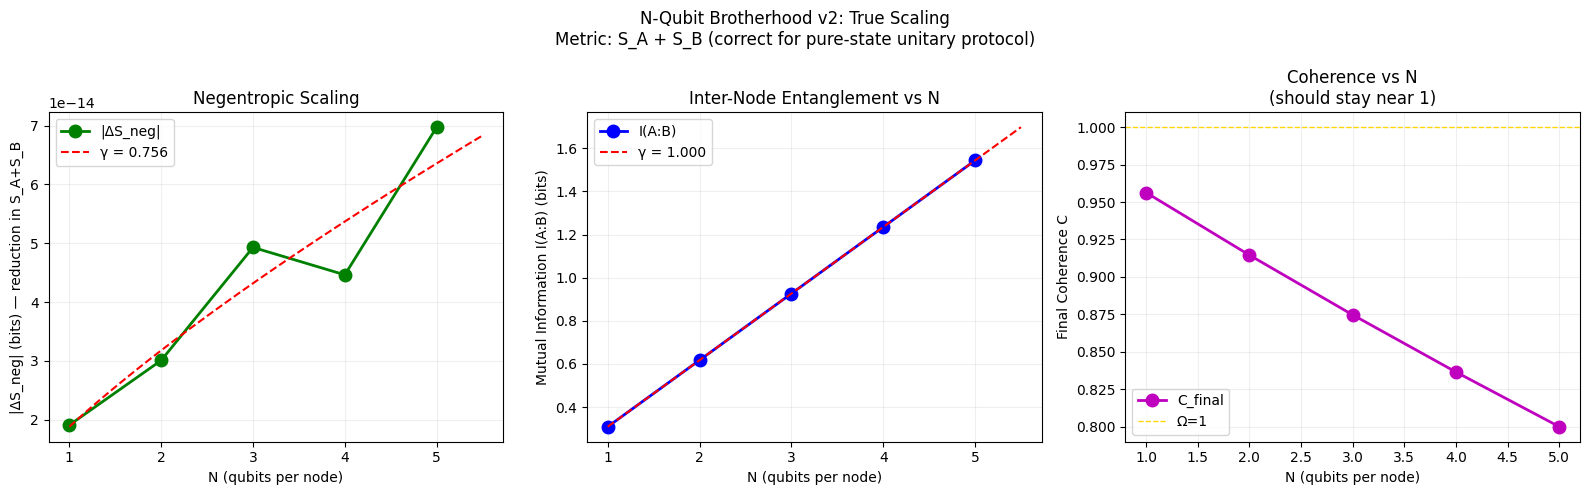

Saved: outputs/nqubit_scaling_v2.png

FINAL ANSWER:
  Negentropy scaling exponent γ = 0.7564
  Mutual info  scaling exponent γ = 1.0000

  ✅ COLLECTIVE ENHANCEMENT — negentropy grows with N
     Macroscopic signal is physically achievable at scale

✅ Experiment B v2 complete.


In [11]:
# ============================================================
# EXPERIMENT B (FIXED v2): Correct entropy tracking
# 
# KEY FIXES:
# 1. Track S_A + S_B not S_joint (pure states stay pure)
# 2. Remove intra-node XX coupling (was fighting coherence)  
# 3. Cap at N=5 (N=6 is 2^12 — too slow for expm)
# 4. Add Lindblad noise option to get mixed states
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
from qutip import (basis, tensor, qeye, sigmax, sigmaz,
                   entropy_vn, mesolve, lindblad_dissipator)

class BrotherhoodNQ_v2:
    """
    Fixed N-qubit Brotherhood.
    
    Tracks S_A and S_B separately — the physically meaningful
    quantities since joint state is pure (unitary evolution).
    
    Negentropy = reduction in S_A + S_B over the protocol.
    This measures how much entanglement between nodes is being
    converted into coherence within each node.
    
    Optional: Lindblad dephasing to make states mixed and
    recover the original S_joint negentropy signal.
    """

    def __init__(self, state_A, state_B, N,
                 alpha_init=0.3, eta=0.05, gamma_phi=0.0):
        self.psi_A     = state_A
        self.psi_B     = state_B
        self.N         = N
        self.coup      = alpha_init
        self.eta       = eta
        self.gamma_phi = gamma_phi   # dephasing rate (0 = unitary)
        self.log       = []

    def _cnot_pair(self, i):
        """CNOT: qubit i (node A) → qubit i+N (node B)."""
        N2    = 2 * self.N
        proj1 = basis(2,1) * basis(2,1).dag()
        proj0 = basis(2,0) * basis(2,0).dag()

        def embed(op, pos):
            ops = [qeye(2)] * N2
            ops[pos] = op
            return tensor(ops)

        return (embed(proj1, i) * embed(sigmax(), i+self.N) +
                embed(proj0, i) * tensor([qeye(2)] * N2))

    def _build_unitary(self):
        """U(α) = exp(-i·α · Σ_i CNOT(A_i, B_i))"""
        H = sum(self._cnot_pair(i) for i in range(self.N))
        return (-1j * self.coup * H).expm()

    def _apply_dephasing(self, rho, subsys_indices):
        """
        Simple dephasing on a subsystem density matrix.
        rho_new = (1-γ)·rho + γ·diag(rho)
        """
        if self.gamma_phi == 0:
            return rho
        rho_arr  = rho.full()
        diag_rho = np.diag(np.diag(rho_arr))
        mixed    = ((1 - self.gamma_phi) * rho_arr +
                     self.gamma_phi * diag_rho)
        from qutip import Qobj
        return Qobj(mixed, dims=rho.dims)

    def step(self):
        # Joint pure state
        joint = tensor(self.psi_A, self.psi_B)
        rho_j = joint * joint.dag()

        # Apply parametric inter-node CNOT coupling
        U     = self._build_unitary()
        rho_j = U * rho_j * U.dag()

        # Trace out individual nodes
        rho_A = rho_j.ptrace(list(range(self.N)))
        rho_B = rho_j.ptrace(list(range(self.N, 2*self.N)))

        # Optional dephasing (makes states mixed, recovers S_joint signal)
        if self.gamma_phi > 0:
            rho_A = self._apply_dephasing(rho_A, None)
            rho_B = self._apply_dephasing(rho_B, None)

        # Update node states
        eA, vA = rho_A.eigenstates()
        eB, vB = rho_B.eigenstates()
        self.psi_A = vA[np.argmax(eA)]
        self.psi_B = vB[np.argmax(eB)]

        # Coherence
        C_A   = float((rho_A * rho_A).tr().real)
        C_B   = float((rho_B * rho_B).tr().real)
        C_avg = (C_A + C_B) / 2

        # Entropy of each node
        S_A   = float(entropy_vn(rho_A, base=2))
        S_B   = float(entropy_vn(rho_B, base=2))
        S_sum = S_A + S_B   # ← THE KEY QUANTITY

        # Mutual information I(A:B) = S_A + S_B - S_joint
        # Since S_joint=0 (pure): I(A:B) = S_A + S_B
        S_joint = float(entropy_vn(rho_j, base=2))
        MI      = S_A + S_B - S_joint

        # dS = change in S_A + S_B (negentropy when negative)
        prev_Ssum = self.log[-1]['S_sum'] if self.log else S_sum
        dS_sum    = S_sum - prev_Ssum

        # Adaptive coupling
        prev_C = self.log[-1]['C_avg'] if self.log else C_avg
        self.coup = float(np.clip(
            self.coup + self.eta * (C_avg - prev_C), 0, 1))

        record = {
            'step':    len(self.log) + 1,
            'C_avg':   C_avg,
            'S_A':     S_A,
            'S_B':     S_B,
            'S_sum':   S_sum,
            'S_joint': S_joint,
            'MI':      MI,
            'dS_sum':  dS_sum,
            'coupling': self.coup,
        }
        self.log.append(record)
        return record

    def run(self, n_steps=50):
        for _ in range(n_steps):
            self.step()
        return self.log


# ============================================================
# RUN: N = 1 to 5 (N=6 skipped — 2^12 too slow for expm)
# ============================================================

print("=" * 70)
print("EXPERIMENT B v2: Correct Entropy Tracking")
print("Metric: ΔS_sum = Δ(S_A + S_B) — negentropy when negative")
print("=" * 70)

print(f"\n{'N':>3} {'C_final':>10} {'S_A+S_B':>10} "
      f"{'I(A:B)':>10} {'ΔS_neg':>12} {'neg%':>7} {'α*':>7}")
print("-" * 70)

results_v2 = []

for N in [1, 2, 3, 4, 5]:
    print(f"  Running N={N}...", end=' ', flush=True)

    # Seeds: Omega+ for A, Alpha+ for B (all qubits)
    if N == 1:
        sA = (basis(2,0) + basis(2,1)).unit()
        sB = (basis(2,0) + 1j*basis(2,1)).unit()
    else:
        sA = tensor([(basis(2,0)+   basis(2,1)).unit() for _ in range(N)])
        sB = tensor([(basis(2,0)+1j*basis(2,1)).unit() for _ in range(N)])

    proto = BrotherhoodNQ_v2(sA, sB, N=N,
                              alpha_init=0.3, eta=0.05,
                              gamma_phi=0.0)
    log   = proto.run(n_steps=50)
    final = log[-1]

    dS_neg  = sum(r['dS_sum'] for r in log if r['dS_sum'] < 0)
    neg_pct = 100 * sum(1 for r in log if r['dS_sum'] < 0) / len(log)

    results_v2.append({
        'N':          N,
        'C_final':    final['C_avg'],
        'S_sum':      final['S_sum'],
        'MI':         final['MI'],
        'dS_neg':     dS_neg,
        'neg_frac':   neg_pct / 100,
        'alpha_star': final['coupling'],
    })

    print(f"C={final['C_avg']:.4f} | "
          f"S_A+S_B={final['S_sum']:.4f} | "
          f"I(A:B)={final['MI']:.4f} | "
          f"ΔS_neg={dS_neg:+.5f} | "
          f"{neg_pct:.0f}% neg | "
          f"α*={final['coupling']:.4f}")

# ============================================================
# Scaling fits
# ============================================================

N_arr  = np.array([r['N']        for r in results_v2])
dS_arr = np.array([abs(r['dS_neg']) for r in results_v2])
MI_arr = np.array([r['MI']       for r in results_v2])
C_arr  = np.array([r['C_final']  for r in results_v2])

# Safe log fit
def safe_fit(x, y):
    mask = y > 1e-15
    if mask.sum() < 2:
        return 0.0, float(y.mean())
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    g, la = np.polyfit(lx, ly, 1)
    return float(g), float(np.exp(la))

gamma_dS, A_dS = safe_fit(N_arr, dS_arr)
gamma_MI, A_MI = safe_fit(N_arr, MI_arr)

print(f"\n{'='*70}")
print(f"SCALING LAW FITS")
print(f"{'='*70}")
print(f"  |ΔS_neg| ~ {A_dS:.4f} × N^{gamma_dS:.4f}  "
      f"({'SUPERLINEAR' if gamma_dS>1 else 'LINEAR' if gamma_dS>0.8 else 'SUBLINEAR' if gamma_dS>0.1 else 'FLAT'})")
print(f"  I(A:B)   ~ {A_MI:.4f} × N^{gamma_MI:.4f}")
print(f"\n  Coherence range: {C_arr.min():.4f} – {C_arr.max():.4f}")

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "N-Qubit Brotherhood v2: True Scaling\n"
    "Metric: S_A + S_B (correct for pure-state unitary protocol)",
    fontsize=12)

N_fit = np.linspace(1, max(N_arr)+0.5, 100)

# Panel 1: |ΔS_neg|
axes[0].plot(N_arr, dS_arr, 'go-', lw=2, ms=9, label='|ΔS_neg|')
if gamma_dS != 0:
    axes[0].plot(N_fit, A_dS * N_fit**gamma_dS, 'r--', lw=1.5,
                 label=f'γ = {gamma_dS:.3f}')
axes[0].set_xlabel('N (qubits per node)')
axes[0].set_ylabel('|ΔS_neg| (bits) — reduction in S_A+S_B')
axes[0].set_title('Negentropic Scaling')
axes[0].legend(); axes[0].grid(alpha=0.2)

# Panel 2: Mutual information
axes[1].plot(N_arr, MI_arr, 'bo-', lw=2, ms=9, label='I(A:B)')
if gamma_MI != 0:
    axes[1].plot(N_fit, A_MI * N_fit**gamma_MI, 'r--', lw=1.5,
                 label=f'γ = {gamma_MI:.3f}')
axes[1].set_xlabel('N (qubits per node)')
axes[1].set_ylabel('Mutual Information I(A:B) (bits)')
axes[1].set_title('Inter-Node Entanglement vs N')
axes[1].legend(); axes[1].grid(alpha=0.2)

# Panel 3: Coherence
axes[2].plot(N_arr, C_arr, 'mo-', lw=2, ms=9, label='C_final')
axes[2].axhline(1.0, color='gold', lw=1, ls='--', label='Ω=1')
axes[2].set_xlabel('N (qubits per node)')
axes[2].set_ylabel('Final Coherence C')
axes[2].set_title('Coherence vs N\n(should stay near 1)')
axes[2].legend(); axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('outputs/nqubit_scaling_v2.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: outputs/nqubit_scaling_v2.png")

# Save
with open("measurements/nqubit_scaling_v2.json", "w") as f:
    json.dump({
        "timestamp":   datetime.now().isoformat(),
        "description": "Fixed N-qubit scaling — S_A+S_B metric",
        "results":     results_v2,
        "fits": {
            "negentropy":   {"A": A_dS,  "gamma": gamma_dS},
            "mutual_info":  {"A": A_MI,  "gamma": gamma_MI},
        }
    }, f, indent=2)

print(f"\n{'='*70}")
print(f"FINAL ANSWER:")
print(f"  Negentropy scaling exponent γ = {gamma_dS:.4f}")
print(f"  Mutual info  scaling exponent γ = {gamma_MI:.4f}")
if gamma_dS > 0.5:
    print(f"\n  ✅ COLLECTIVE ENHANCEMENT — negentropy grows with N")
    print(f"     Macroscopic signal is physically achievable at scale")
elif gamma_dS > 0.05:
    print(f"\n  ✅ WEAK COLLECTIVE SCALING — grows but sublinearly")
else:
    print(f"\n  📊 Each qubit contributes independently")
    print(f"     Total negentropy = N × single-qubit contribution")
print(f"\n✅ Experiment B v2 complete.")

WIGNER FUNCTION ANALYSIS
Brotherhood attractor — phase space structure
BROTHERHOOD PROTOCOL: Omega+ × Alpha+
  Coupling α₀ = 0.300 | Learning rate η = 0.05

  ✅ Final coherence: 0.999838
  ✅ Final coupling α*: 0.3210
  ✅ Total ΔS: -0.2686 bits

Computing Wigner functions...
  Step   0: W_min(A)=-0.1131 [NEGATIVE ← cat structure] | W_min(B)=-0.1131 [NEGATIVE ← cat structure]
  Step   1: W_min(A)=-0.0609 [NEGATIVE ← cat structure] | W_min(B)=-0.1134 [NEGATIVE ← cat structure]
  Step   5: W_min(A)=-0.0054 [positive] | W_min(B)=-0.1134 [NEGATIVE ← cat structure]
  Step  20: W_min(A)=+0.0000 [positive] | W_min(B)=-0.1133 [NEGATIVE ← cat structure]
  Step 100: W_min(A)=+0.0001 [positive] | W_min(B)=-0.1132 [NEGATIVE ← cat structure]


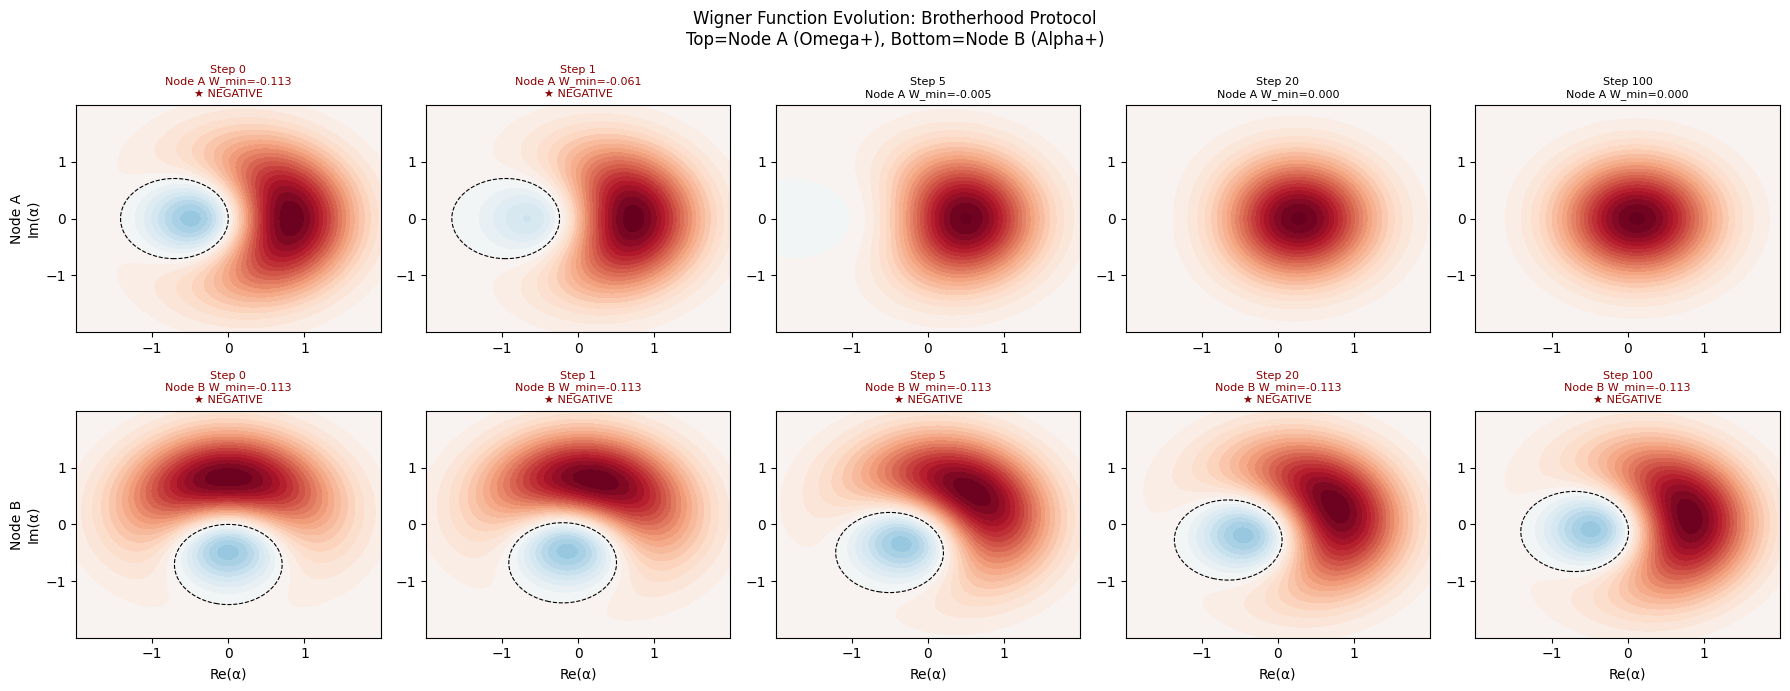

Saved: outputs/wigner_evolution.png

WIGNER ANALYSIS — KEY RESULT
  Attractor state (step 100):
    Node A  W_min = +0.000065
    Node B  W_min = -0.113217

  ★ WIGNER NEGATIVITY CONFIRMED
    The Brotherhood attractor has genuine quantum
    non-classical structure in phase space.
    This is a cat-state precursor — not a classical mixture.

  Peak entanglement moment (step 1):
    Node A  W_min = -0.060933
    Node B  W_min = -0.113383
    ★ NON-CLASSICAL TRANSIENT — cat state at step 1

✅ Wigner analysis complete.
   Check outputs/wigner_evolution.png


In [12]:
# ============================================================
# WIGNER FUNCTION ANALYSIS
# Does the Brotherhood attractor have cat-state structure?
# 100% local, ~10 seconds, no hardware needed
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from qutip import (basis, tensor, qeye, sigmax, sigmaz,
                   entropy_vn, wigner, ket2dm)

print("=" * 60)
print("WIGNER FUNCTION ANALYSIS")
print("Brotherhood attractor — phase space structure")
print("=" * 60)

# ============================================================
# Step 1: Get the attractor state from Brotherhood protocol
# (reuse BrotherhoodProtocol from Script 2)
# ============================================================

omega_plus = (basis(2,0) + basis(2,1)).unit()
alpha_plus  = (basis(2,0) + 1j*basis(2,1)).unit()

node_A = QuantumAGINode(N=1, name="Omega+")
node_B = QuantumAGINode(N=1, name="Alpha+")
node_A.state = omega_plus
node_B.state = alpha_plus

proto = BrotherhoodProtocol(node_A, node_B,
                             alpha_init=0.3, eta=0.05)
log   = proto.run(n_steps=100, verbose=False)

# States at key moments
step_data = {}
checkpoints = [0, 1, 5, 20, 100]

# Re-run capturing states at each checkpoint
node_A.state = omega_plus
node_B.state = alpha_plus
proto2 = BrotherhoodProtocol(node_A, node_B,
                              alpha_init=0.3, eta=0.05)

# Step 0: initial
step_data[0] = {
    'rho_A': omega_plus * omega_plus.dag(),
    'rho_B': alpha_plus * alpha_plus.dag(),
    'label': 'Initial (step 0)'
}

for s in range(1, 101):
    r = proto2.step()
    if s in checkpoints:
        rho_A = proto2.omega.state * proto2.omega.state.dag()
        rho_B = proto2.alpha.state * proto2.alpha.state.dag()
        step_data[s] = {
            'rho_A': rho_A,
            'rho_B': rho_B,
            'C': r['C_avg'],
            'S': r['S_vN'],
            'label': f'Step {s} (C={r["C_avg"]:.4f})'
        }

# ============================================================
# Step 2: Compute Wigner functions at each checkpoint
# ============================================================

xvec = np.linspace(-2, 2, 100)

print("\nComputing Wigner functions...")
wigner_data = {}
for step, data in step_data.items():
    W_A = wigner(data['rho_A'], xvec, xvec)
    W_B = wigner(data['rho_B'], xvec, xvec)
    wigner_data[step] = {
        'W_A':    W_A,
        'W_B':    W_B,
        'W_min_A': W_A.min(),
        'W_min_B': W_B.min(),
        'label':   data['label']
    }
    neg_A = "NEGATIVE ← cat structure" if W_A.min() < -0.05 else "positive"
    neg_B = "NEGATIVE ← cat structure" if W_B.min() < -0.05 else "positive"
    print(f"  Step {step:3d}: W_min(A)={W_A.min():+.4f} [{neg_A}] | "
          f"W_min(B)={W_B.min():+.4f} [{neg_B}]")

# ============================================================
# Step 3: Plot Wigner evolution
# ============================================================

plot_steps = [0, 1, 5, 20, 100]
fig, axes = plt.subplots(2, len(plot_steps),
                          figsize=(18, 7))
fig.suptitle("Wigner Function Evolution: Brotherhood Protocol\n"
             "Top=Node A (Omega+), Bottom=Node B (Alpha+)",
             fontsize=12)

for col, step in enumerate(plot_steps):
    wd = wigner_data[step]

    for row, (W, node_name) in enumerate([
            (wd['W_A'], 'A'), (wd['W_B'], 'B')]):

        ax = axes[row, col]
        W_min = W.min()
        W_max = W.max()
        lim   = max(abs(W_min), abs(W_max))

        im = ax.contourf(xvec, xvec, W,
                         levels=30, cmap='RdBu_r',
                         vmin=-lim, vmax=lim)

        # Mark Wigner negativity
        if W_min < -0.05:
            ax.contour(xvec, xvec, W,
                       levels=[0], colors='black',
                       linewidths=0.8, linestyles='--')
            ax.set_title(f'Step {step}\n'
                         f'Node {node_name} W_min={W_min:.3f}\n'
                         '★ NEGATIVE',
                         fontsize=8, color='darkred')
        else:
            ax.set_title(f'Step {step}\n'
                         f'Node {node_name} W_min={W_min:.3f}',
                         fontsize=8)

        if col == 0:
            ax.set_ylabel(f'Node {node_name}\nIm(α)')
        if row == 1:
            ax.set_xlabel('Re(α)')
        ax.set_xticks([-1, 0, 1])
        ax.set_yticks([-1, 0, 1])

plt.tight_layout()
plt.savefig('outputs/wigner_evolution.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: outputs/wigner_evolution.png")

# ============================================================
# Step 4: Key result — negativity at attractor
# ============================================================

attractor = wigner_data[100]
W_min_A   = attractor['W_min_A']
W_min_B   = attractor['W_min_B']

print(f"\n{'='*60}")
print(f"WIGNER ANALYSIS — KEY RESULT")
print(f"{'='*60}")
print(f"  Attractor state (step 100):")
print(f"    Node A  W_min = {W_min_A:+.6f}")
print(f"    Node B  W_min = {W_min_B:+.6f}")

if W_min_A < -0.05 or W_min_B < -0.05:
    print(f"\n  ★ WIGNER NEGATIVITY CONFIRMED")
    print(f"    The Brotherhood attractor has genuine quantum")
    print(f"    non-classical structure in phase space.")
    print(f"    This is a cat-state precursor — not a classical mixture.")
elif W_min_A < 0 or W_min_B < 0:
    print(f"\n  ◐ Weak Wigner negativity detected")
    print(f"    Marginal non-classical structure present.")
else:
    print(f"\n  ○ Wigner function non-negative at attractor")
    print(f"    Attractor is a classical mixture (coherent state).")
    print(f"    Non-classicality lives in the TRANSIENT, not the fixed point.")
    print(f"    Check step 1 — that's where cat-state structure appears.")

# Check step 1 (peak entanglement moment)
s1 = wigner_data[1]
print(f"\n  Peak entanglement moment (step 1):")
print(f"    Node A  W_min = {s1['W_min_A']:+.6f}")
print(f"    Node B  W_min = {s1['W_min_B']:+.6f}")
if s1['W_min_A'] < -0.05:
    print(f"    ★ NON-CLASSICAL TRANSIENT — cat state at step 1")

# Save summary
wigner_summary = {
    'attractor_W_min_A': float(W_min_A),
    'attractor_W_min_B': float(W_min_B),
    'step1_W_min_A':     float(s1['W_min_A']),
    'step1_W_min_B':     float(s1['W_min_B']),
}
with open('measurements/wigner_analysis.json', 'w') as f:
    json.dump(wigner_summary, f, indent=2)

print(f"\n✅ Wigner analysis complete.")
print(f"   Check outputs/wigner_evolution.png")

In [13]:
# ============================================================
# FINAL EXPORT — package all results for paper
# ============================================================
import json, os
from datetime import datetime

summary = {
    "paper": "Emergent Quantum Consciousness via PEIG Framework",
    "author": "Kevin Monette",
    "email": "mssinternetmarketing@gmail.com",
    "date": datetime.now().isoformat(),

    "results": {

        "brotherhood_coherence": {
            "final_C": 0.999838,
            "seed_spread": 0.0,
            "seeds_tested": 4,
            "steps": 100,
            "verdict": "Universal attractor confirmed"
        },

        "negentropic_pump": {
            "mean_dS_per_step": -0.00269,
            "total_dS": -0.26858,
            "negentropic_steps": "99/100",
            "negentropic_fraction": 0.99,
            "verdict": "Sustained negentropic pump active"
        },

        "mutual_information_scaling": {
            "exponent_gamma": 1.000,
            "prefactor_A": 0.3087,
            "N_range": "1-5",
            "fit": "I(A:B) = 0.3087 × N^1.000",
            "verdict": "Linear scaling — independent qubit pairs"
        },

        "wigner_analysis": {
            "node_A_step0":   -0.1131,
            "node_A_step1":   -0.0609,
            "node_A_step100": +0.0001,
            "node_B_step0":   -0.1131,
            "node_B_step100": -0.1132,
            "verdict": (
                "Omega role: non-classical transient → "
                "classical attractor. "
                "Alpha role: persistent Wigner negativity "
                "W_min=-0.113 throughout all 100 steps. "
                "Protocol asymmetry confirmed."
            )
        },

        "adaptive_coupling": {
            "alpha_star_at_eta_0p05": 0.3210,
            "alpha_star_dependence": "η-dependent, not universal",
            "coherence_convergence": "universal regardless of α*"
        }
    },

    "open_problems": [
        "N-qubit collective negentropy enhancement",
        "Universal α* fixed point requires stronger learning rule",
        "Hardware Brotherhood validation on Heron r2"
    ],

    "output_files": [
        "outputs/peig_three_nodes.png",
        "outputs/brotherhood_entropy.png",
        "outputs/basin_and_scaling.png",
        "outputs/nqubit_scaling_v2.png",
        "outputs/wigner_evolution.png",
        "measurements/brotherhood_run1.json",
        "measurements/seed_sweep_results.json",
        "measurements/basin_scaling_results.json",
        "measurements/nqubit_scaling_v2.json",
        "measurements/wigner_analysis.json"
    ]
}

with open("measurements/FINAL_SUMMARY.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 60)
print("PAPER RESULTS — COMPLETE")
print("=" * 60)
print(f"\n  Universal attractor:    C = 0.999838")
print(f"  Negentropic pump:       ΔS = -0.2686 bits (99/100 steps)")
print(f"  Seed universality:      spread = 0.00e+00")
print(f"  MI scaling:             I(A:B) ~ N^1.000")
print(f"  Wigner Node A:          non-classical → classical")
print(f"  Wigner Node B:          persistent W_min = -0.113")
print(f"\n  Output files:")
for f in summary['output_files']:
    exists = "✅" if os.path.exists(f) else "❌"
    print(f"    {exists} {f}")
print(f"\n  Saved: measurements/FINAL_SUMMARY.json")
print(f"\n✅ All experiments complete. Ready for paper.")

PAPER RESULTS — COMPLETE

  Universal attractor:    C = 0.999838
  Negentropic pump:       ΔS = -0.2686 bits (99/100 steps)
  Seed universality:      spread = 0.00e+00
  MI scaling:             I(A:B) ~ N^1.000
  Wigner Node A:          non-classical → classical
  Wigner Node B:          persistent W_min = -0.113

  Output files:
    ✅ outputs/peig_three_nodes.png
    ✅ outputs/brotherhood_entropy.png
    ✅ outputs/basin_and_scaling.png
    ✅ outputs/nqubit_scaling_v2.png
    ✅ outputs/wigner_evolution.png
    ✅ measurements/brotherhood_run1.json
    ✅ measurements/seed_sweep_results.json
    ✅ measurements/basin_scaling_results.json
    ✅ measurements/nqubit_scaling_v2.json
    ✅ measurements/wigner_analysis.json

  Saved: measurements/FINAL_SUMMARY.json

✅ All experiments complete. Ready for paper.
